# **ANÁLISIS DE GEOLOGÍA**

### **MAPA GEOLÓGICO GENERAL DEL VALLE DE ABURRÁ**

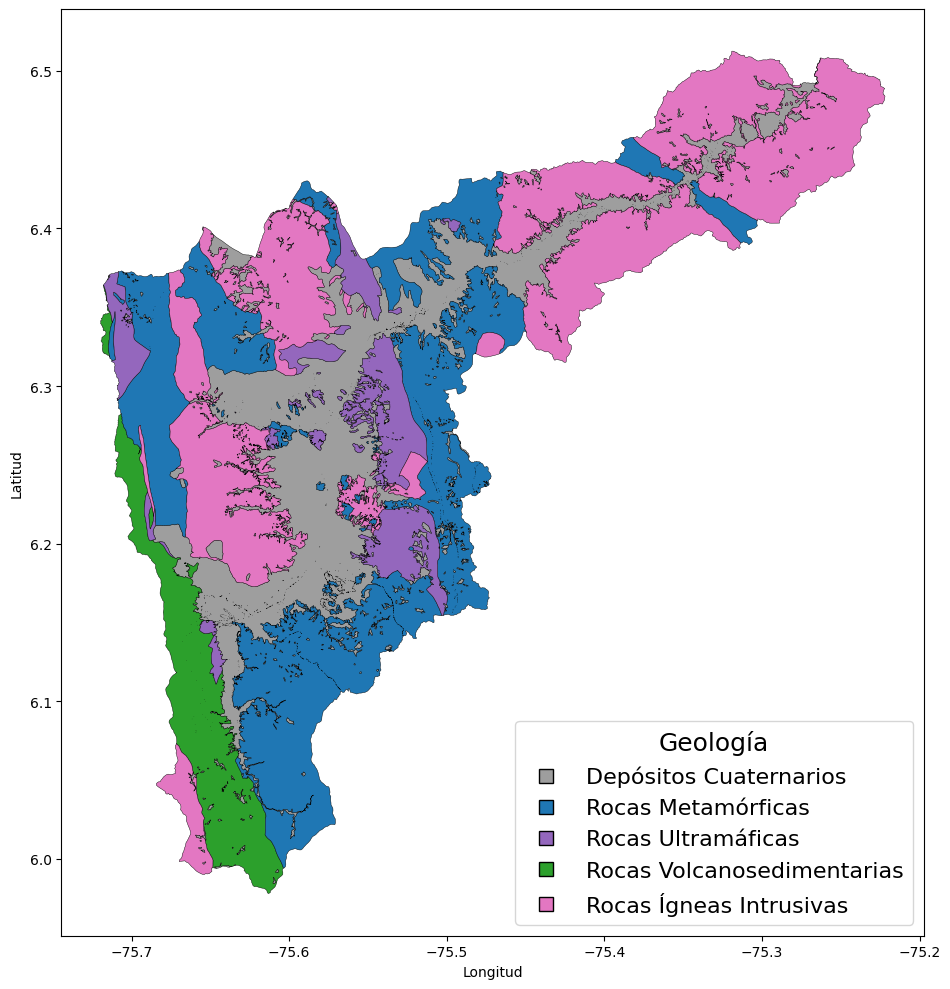

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1) Cargar
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
geo = gpd.read_file(geo_path, encoding="utf-8")

# 2) Asegurar que la columna exista y sea categórica (mejor para la leyenda)
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile."
geo["Geologia"] = geo["Geologia"].astype("category")

# 3) Graficar con leyenda automática
# --- 3) Graficar ---
import unicodedata
from matplotlib.lines import Line2D

# --- Normalizador (sin tildes, minúsculas) ---
def _norm(s):
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# --- Mapa de colores por categoría (claves normalizadas) ---
color_map_norm = {
    "depositos cuaternarios":        "#9e9e9e",  # gris
    "rocas metamorficas":            "#1f77b4",  # azul
    "rocas ultramaficas":            "#9467bd",  # morado
    "rocas volcanosedimentarias":    "#2ca02c",  # verde
    "rocas igneas intrusivas":       "#e377c2",  # rosado
}


# Mejor: que 'Geologia' NO sea categoría durante el mapeo
geo["Geologia"] = geo["Geologia"].astype(str)

geo["Geologia_norm"] = geo["Geologia"].apply(_norm)
s = geo["Geologia_norm"].map(color_map_norm)

geo["fillcolor"] = s.astype("object").fillna("#cccccc")
# --- Graficar con colores fijos ---
fig, ax = plt.subplots(figsize=(10, 10))

# Geología
geo.plot(ax=ax, facecolor=geo["fillcolor"], edgecolor="black", linewidth=0.3)

#ax.set_title("Mapa de Unidades Geológicas + Inventario de Deslizamientos", fontsize=14)
ax.set_xlabel("Longitud" if geo.crs is None or (geo.crs and geo.crs.is_geographic) else "X (m)")
ax.set_ylabel("Latitud" if geo.crs is None or (geo.crs and geo.crs.is_geographic) else "Y (m)")
ax.set_aspect("equal")

# --- Leyenda manual en orden deseado + deslizamientos ---
orden_legenda = [
    ("Depósitos Cuaternarios",      "#9e9e9e"),
    ("Rocas Metamórficas",          "#1f77b4"),
    ("Rocas Ultramáficas",          "#9467bd"),
    ("Rocas Volcanosedimentarias",  "#2ca02c"),
    ("Rocas Ígneas Intrusivas",     "#e377c2"),
]

handles_geo = [Line2D([0], [0], marker='s', linestyle='',
                      markerfacecolor=c, markeredgecolor='black',
                      markersize=10, label=lab) for lab, c in orden_legenda]

labels_geo = [lab for lab, _ in orden_legenda]
labels = labels_geo

ax.legend(handles=handles_geo,
          labels=labels,
          title="Geología",
          loc="lower right", frameon=True, fontsize=16, title_fontsize=18)



plt.tight_layout()
plt.show()


### **MAPA GEOLÓGICO GENERAL DEL VALLE DE ABURRÁ CON EL INVENTARIO DE DESLIZAMIENTOS DE SENSORES REMOTOS**

Puntos antes: 5759 | Puntos dentro de geología: 5744


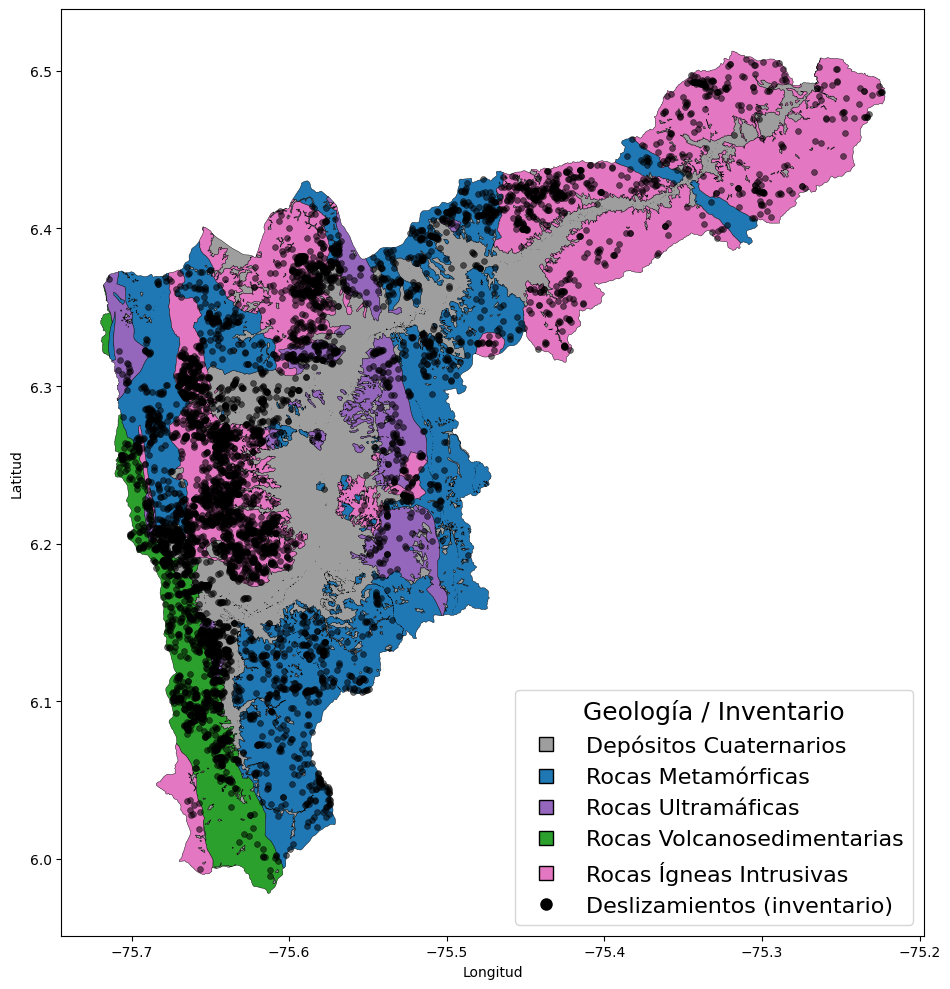

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2DC

# --- Rutas ---
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/sensores_remotos_amva.geojson"

# --- 1) Cargar geología ---
geo = gpd.read_file(geo_path, encoding="utf-8")
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
geo["Geologia"] = geo["Geologia"].astype("category")

# (Opcional pero recomendado para escala/norte correctos)
# geo = geo.to_crs(32618)  # UTM 18N Valle de Aburrá

# --- 2) Cargar inventario de deslizamientos ---
inv = gpd.read_file(inv_path)

# Si el inventario no tiene CRS, asumimos el mismo que la geología (ajústalo si sabes el EPSG exacto del inventario)
if inv.crs is None and geo.crs is not None:
    inv.set_crs(geo.crs, inplace=True)

# Reproyectar al CRS de geología si difieren
if geo.crs is not None and inv.crs is not None and inv.crs != geo.crs:
    inv = inv.to_crs(geo.crs)

# --- 2.b) QUEDARSE SOLO CON LOS PUNTOS DENTRO DE GEOLOGÍA ---
inv_before = len(inv)

# Asegura geometrías válidas (evita topologías raras)
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)  # o usa shapely.make_valid si tienes Shapely 2.x

# Recortar (clip) los puntos del inventario al polígono de geología
inv = gpd.clip(inv, geo_valid)

print(f"Puntos antes: {inv_before} | Puntos dentro de geología: {len(inv)}")
# Si por alguna razón el inventario viene en polígonos/líneas y quieres puntos:
# inv = inv.copy()
# inv["geometry"] = inv.geometry.centroid

# --- 3) Graficar ---
import unicodedata
from matplotlib.lines import Line2D

# --- Normalizador (sin tildes, minúsculas) ---
def _norm(s):
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# --- Mapa de colores por categoría (claves normalizadas) ---
color_map_norm = {
    "depositos cuaternarios":        "#9e9e9e",  # gris
    "rocas metamorficas":            "#1f77b4",  # azul
    "rocas ultramaficas":            "#9467bd",  # morado
    "rocas volcanosedimentarias":    "#2ca02c",  # verde
    "rocas igneas intrusivas":       "#e377c2",  # rosado
}


# Mejor: que 'Geologia' NO sea categoría durante el mapeo
geo["Geologia"] = geo["Geologia"].astype(str)

geo["Geologia_norm"] = geo["Geologia"].apply(_norm)
s = geo["Geologia_norm"].map(color_map_norm)

geo["fillcolor"] = s.astype("object").fillna("#cccccc")
# --- Graficar con colores fijos ---
fig, ax = plt.subplots(figsize=(10, 10))

# Geología
geo.plot(ax=ax, facecolor=geo["fillcolor"], edgecolor="black", linewidth=0.3)

# Inventario (como ya lo tienes)
inv.plot(ax=ax, marker="o", color="black",
         edgecolor="black", linewidth=0.5,
         markersize=18, alpha=0.55, zorder=5)

#ax.set_title("Mapa de Unidades Geológicas + Inventario de Deslizamientos", fontsize=14)
ax.set_xlabel("Longitud" if geo.crs is None or (geo.crs and geo.crs.is_geographic) else "X (m)")
ax.set_ylabel("Latitud" if geo.crs is None or (geo.crs and geo.crs.is_geographic) else "Y (m)")
ax.set_aspect("equal")

# --- Leyenda manual en orden deseado + deslizamientos ---
orden_legenda = [
    ("Depósitos Cuaternarios",      "#9e9e9e"),
    ("Rocas Metamórficas",          "#1f77b4"),
    ("Rocas Ultramáficas",          "#9467bd"),
    ("Rocas Volcanosedimentarias",  "#2ca02c"),
    ("Rocas Ígneas Intrusivas",     "#e377c2"),
]

handles_geo = [Line2D([0], [0], marker='s', linestyle='',
                      markerfacecolor=c, markeredgecolor='black',
                      markersize=10, label=lab) for lab, c in orden_legenda]

handle_inv = Line2D([0], [0], marker='o', linestyle='', markerfacecolor='black',
                    markeredgecolor='black', markersize=8, label='Deslizamientos (inventario)')

labels_geo = [lab for lab, _ in orden_legenda]
labels = labels_geo + ["Deslizamientos (inventario)"]

ax.legend(handles=handles_geo + [handle_inv],
          labels=labels,
          title="Geología / Inventario",
          loc="lower right", frameon=True, fontsize=16, title_fontsize=18)


plt.tight_layout()
plt.show()

### **GRAFICO DE BARRAS DE km2 DE CADA TIPO DE ROCA**

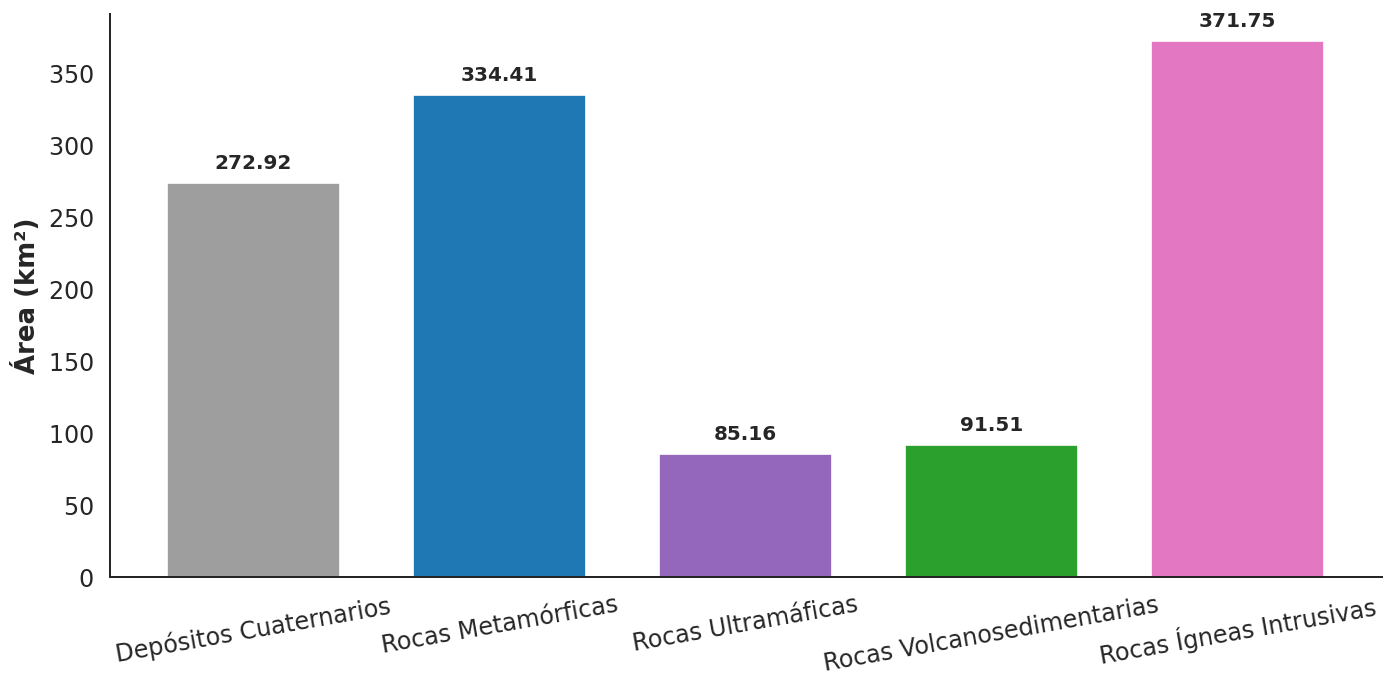

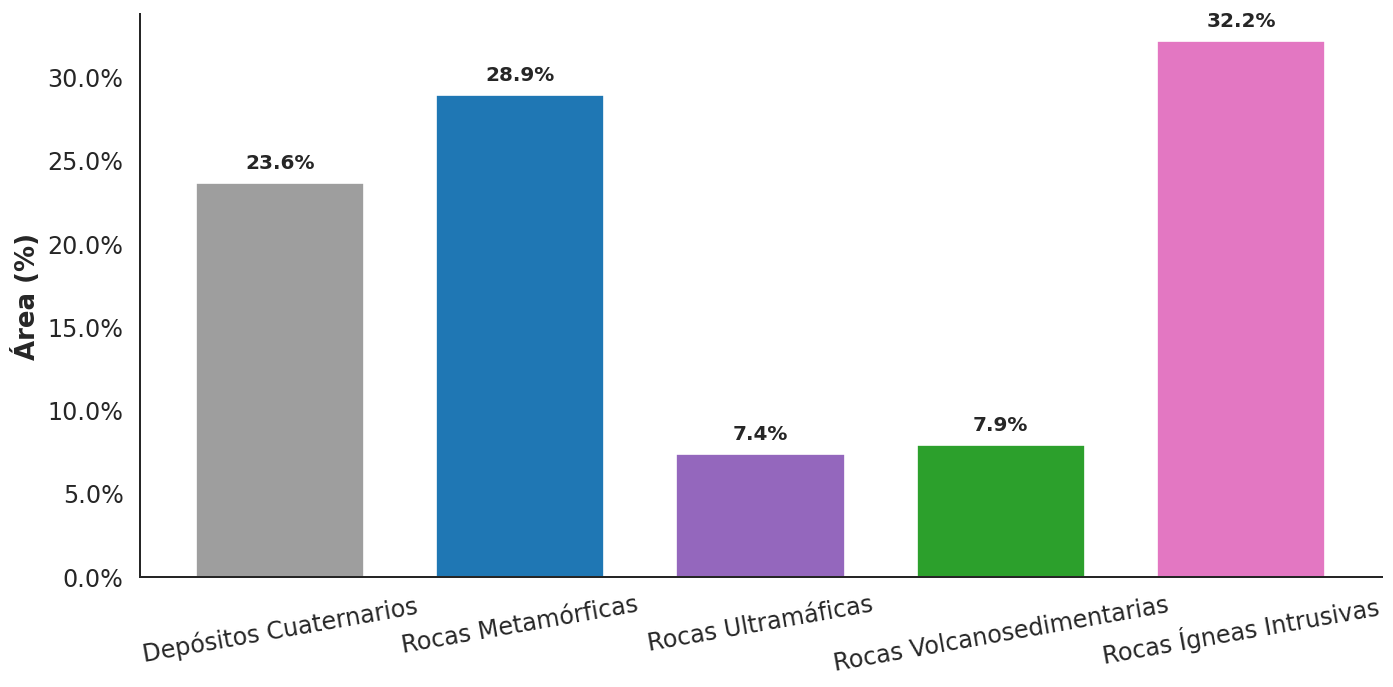

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, PercentFormatter

# --- Normalizador (quita tildes y pasa a minúsculas) ---
def _norm(s):
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# --- Etiquetas “bonitas” y orden deseado en la gráfica ---
orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]

# Mapa normalizada -> etiqueta bonita
norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}

# Mapa etiqueta bonita -> color (idéntico al de tus conteos)
label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",
    "Rocas Metamórficas":         "#1f77b4",
    "Rocas Ultramáficas":         "#9467bd",
    "Rocas Volcanosedimentarias": "#2ca02c",
    "Rocas Ígneas Intrusivas":    "#e377c2",
}

# --- Rutas ------------------------
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"

# ---------- Cargar geología ----------
geo = gpd.read_file(geo_path, encoding="utf-8")
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."

# ---------- Asegurar CRS en metros para área ----------
if geo.crs is None or geo.crs.is_geographic:
    geo = geo.to_crs(32618)   # Usa 3116 si trabajas con MAGNA-SIRGAS oficial

# ---------- Normalizar etiquetas y preparar geometrías ----------
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)         # “make valid” simple
geo_valid["Geologia_norm"]  = geo_valid["Geologia"].apply(_norm)
geo_valid["Geologia_label"] = geo_valid["Geologia_norm"].map(norm_to_label)

# Solo clases de interés
geo_valid = geo_valid.loc[
    geo_valid["Geologia_label"].isin(orden_labels),
    ["Geologia_label", "geometry"]
].copy()

# ---------- Disolver por unidad y calcular área (km²) ----------
geo_diss = geo_valid.dissolve(by="Geologia_label", as_index=True)
geo_diss["area_km2"] = geo_diss.geometry.area / 1e6  # m² → km²

# Tabla de áreas en el orden deseado
df_area = (
    geo_diss[["area_km2"]]
    .reindex(orden_labels)
    .reset_index()
    .rename(columns={"Geologia_label": "Unidad"})
)
df_area["Color"] = df_area["Unidad"].map(label_to_color)

# ---------- Porcentajes ----------
total_km2 = float(df_area["area_km2"].sum(skipna=True))
df_area["pct_area"] = np.where(total_km2 > 0, df_area["area_km2"] / total_km2 * 100.0, 0.0)

# ---------- Gráfico 1: Área (km²) ----------
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(
    df_area["Unidad"],
    df_area["area_km2"],
    color=df_area["Color"],
    width=0.7
)

# Etiquetas encima
y_off1 = (df_area["area_km2"].max() or 0) * 0.02
y_off1 = y_off1 if y_off1 > 0 else 0.05
for bar, a in zip(bars, df_area["area_km2"]):
    if pd.notna(a):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + y_off1,
            f'{a:,.2f}',
            ha='center', va='bottom', fontsize=12, weight='bold'
        )

ax.set_ylabel('Área (km²)', weight='bold'); ax.set_xlabel('')
ax.spines[['right', 'top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2); ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white'); ax.grid(False); ax.tick_params(axis='x', rotation=10)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='plain', useMathText=True)

plt.tight_layout()
plt.show()

# ---------- Gráfico 2: Área en porcentaje ----------
fig2, ax2 = plt.subplots(figsize=(12, 6), dpi=120)

bars2 = ax2.bar(
    df_area["Unidad"],
    df_area["pct_area"],
    color=df_area["Color"],
    width=0.7
)

# Etiquetas encima (con %)
y_off2 = (df_area["pct_area"].max() or 0) * 0.02
y_off2 = y_off2 if y_off2 > 0 else 0.5
for bar, p in zip(bars2, df_area["pct_area"]):
    if pd.notna(p):
        ax2.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + y_off2,
            f'{p:,.1f}%',
            ha='center', va='bottom', fontsize=12, weight='bold'
        )

ax2.set_ylabel('Área (%)', weight='bold'); ax2.set_xlabel('')
ax2.spines[['right', 'top']].set_visible(False)
ax2.spines['left'].set_linewidth(1.2); ax2.spines['bottom'].set_linewidth(1.2)
ax2.set_facecolor('white'); ax2.grid(False); ax2.tick_params(axis='x', rotation=10)
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=100))

plt.tight_layout()
plt.show()

# (Opcional)
# display(df_area[["Unidad","area_km2","pct_area"]])


### **GRAFICO DE BARRAS DE DESLIZAMIENTOS POR TIPO DE ROCA**

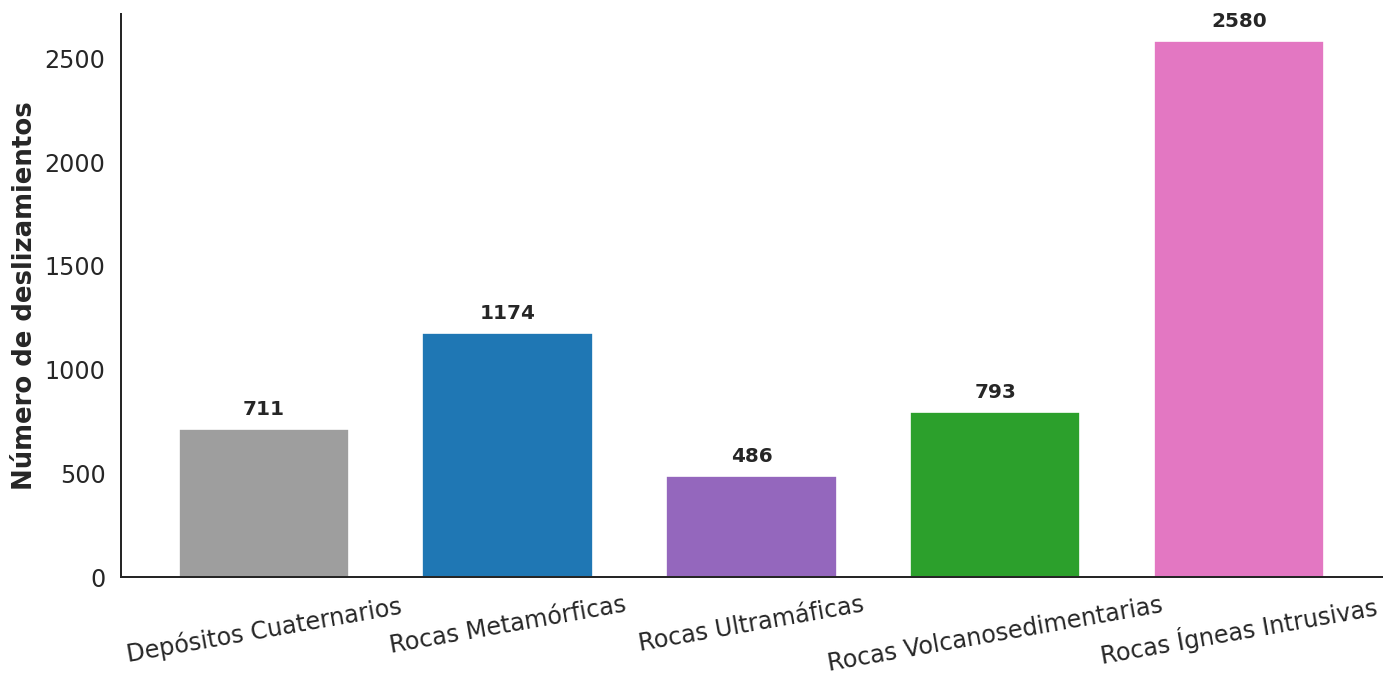

In [5]:
import geopandas as gpd
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# --- Normalizador (quita tildes y pasa a minúsculas) ---
def _norm(s):
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# --- Colores fijos por unidad (claves normalizadas) ---
color_map_norm = {
    "depositos cuaternarios":        "#9e9e9e",  # gris
    "rocas metamorficas":            "#1f77b4",  # azul
    "rocas ultramaficas":            "#9467bd",  # morado
    "rocas volcanosedimentarias":    "#2ca02c",  # verde
    "rocas igneas intrusivas":       "#e377c2",  # rosado
}

# --- Etiquetas “bonitas” y orden deseado en la gráfica ---
orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]
# Mapa etiqueta bonita -> color
label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",
    "Rocas Metamórficas":         "#1f77b4",
    "Rocas Ultramáficas":         "#9467bd",
    "Rocas Volcanosedimentarias": "#2ca02c",
    "Rocas Ígneas Intrusivas":    "#e377c2",
}

# --- Rutas ------------------------
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/sensores_remotos_amva.geojson"
# ---------- Cargar datos ----------
geo = gpd.read_file(geo_path, encoding="utf-8")
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
geo["Geologia"] = geo["Geologia"].astype("category")   
inv = gpd.read_file(inv_path)

# ---------- Asegurar CRS (si hiciera falta) ----------
geo = geo.to_crs(32618)                   # recomendado para V. de Aburrá (m)
inv = inv.to_crs(geo.crs)                 # igualar CRS

# ---------- Clip/sjoin: quedarnos con puntos dentro de geología ----------
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)  # “make valid” simple

# Une puntos con polígonos contenedores
inv_in = gpd.sjoin(inv, geo_valid[["Geologia","geometry"]], how="inner", predicate="within")

# ---------- Agregar conteos por unidad ----------
# Normalizamos para empatar con el dict de colores
inv_in["Geologia_norm"] = inv_in["Geologia"].apply(_norm)

# Creamos etiqueta bonita a partir de la normalizada
norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}
inv_in["Geologia_label"] = inv_in["Geologia_norm"].map(norm_to_label)

# Conteos (incluimos todas las clases del orden, aunque tengan 0)
counts = inv_in.groupby("Geologia_label").size().reindex(orden_labels, fill_value=0)
df_counts = counts.reset_index()
df_counts.columns = ["Unidad", "Conteo"]
df_counts["Color"] = df_counts["Unidad"].map(label_to_color)

# ---------- Graficar (formato similar a tu ejemplo) ----------
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(
    df_counts["Unidad"],
    df_counts["Conteo"],
    color=df_counts["Color"],
    width=0.7
)

# Etiquetas encima de cada barra (conteo entero)
for bar, n in zip(bars, df_counts["Conteo"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(df_counts["Conteo"])*0.02 if df_counts["Conteo"].max() > 0 else 0.2,
        f'{int(n)}',
        ha='center', va='bottom', fontsize=12, weight='bold'
    )

# Ejes y estilo
ax.set_ylabel('Número de deslizamientos', weight='bold')
ax.set_xlabel('')
ax.spines[['right', 'top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white')
ax.grid(False)
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

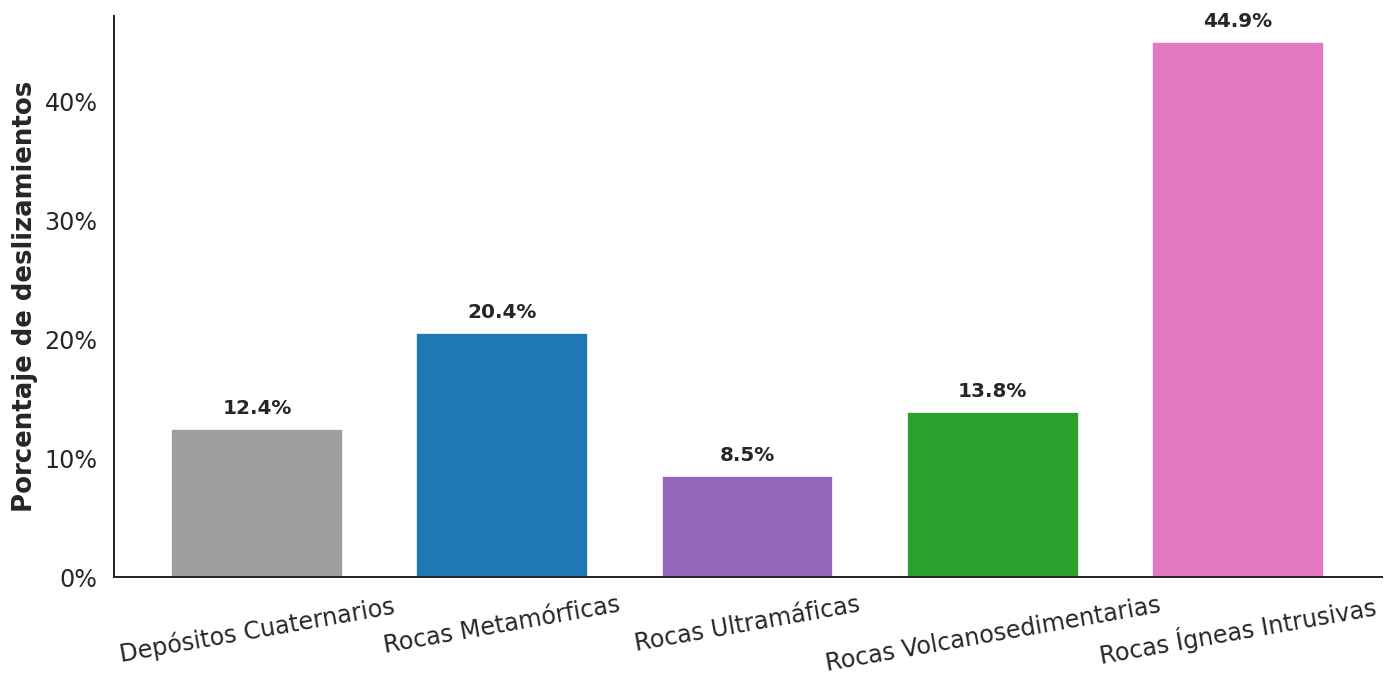

In [10]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata
from matplotlib.ticker import PercentFormatter

# --- Utilidades (usa las que ya tengas) ---
def _norm(s):
    if s is None: return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}

orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]

label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",  # gris
    "Rocas Metamórficas":         "#1f77b4",  # azul
    "Rocas Ultramáficas":         "#9467bd",  # morado
    "Rocas Volcanosedimentarias": "#2ca02c",  # verde
    "Rocas Ígneas Intrusivas":    "#e377c2",  # rosado
}

# --- 1) Asegurar CRS compatible para el join espacial (no hace falta metros para porcentajes) ---
if (geo.crs is not None) and (inv.crs != geo.crs):
    inv = inv.to_crs(geo.crs)

# --- 2) Puntos dentro del área de estudio (geología) ---
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)

inv_in = gpd.sjoin(inv, geo_valid[["Geologia","geometry"]], how="inner", predicate="within")

# --- 3) Conteo por unidad y porcentaje sobre el total (dentro del área de estudio) ---
inv_in["Geologia_norm"]  = inv_in["Geologia"].apply(_norm)
inv_in["Geologia_label"] = inv_in["Geologia_norm"].map(norm_to_label)

counts = inv_in.groupby("Geologia_label").size().reindex(orden_labels, fill_value=0)
total  = counts.sum()

# Evitar división por cero si no hay puntos dentro
pct = (counts / total) if total > 0 else counts.astype(float)

df_pct = pd.DataFrame({
    "Unidad": orden_labels,
    "Porcentaje": pct.values,
    "Color": [label_to_color[u] for u in orden_labels]
})

# --- 4) Gráfico de barras (mismo estilo que tu ejemplo) ---
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(
    df_pct["Unidad"],
    df_pct["Porcentaje"],
    color=df_pct["Color"],
    width=0.7
)

# Etiquetas encima de cada barra (en %)
for bar, p in zip(bars, df_pct["Porcentaje"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        (bar.get_height() if total>0 else 0) + 0.01,
        f'{(p*100 if total>0 else 0):.1f}%',
        ha='center', va='bottom', fontsize=12, weight='bold'
    )

# Eje Y como porcentaje
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

# Etiquetas y estilo
ax.set_ylabel('Porcentaje de deslizamientos', weight='bold')
ax.set_xlabel('')
ax.spines[['right','top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white')
ax.grid(False)
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

# (Opcional) Verificación rápida en consola
# print(pd.DataFrame({"Conteo": counts, "Porcentaje (%)": (pct*100 if total>0 else 0)}))


### **GRAFICO DE BARRAS DENSIDAD DE DESLIZAMIENTOS POR TIPO DE ROCA (N/km²)**

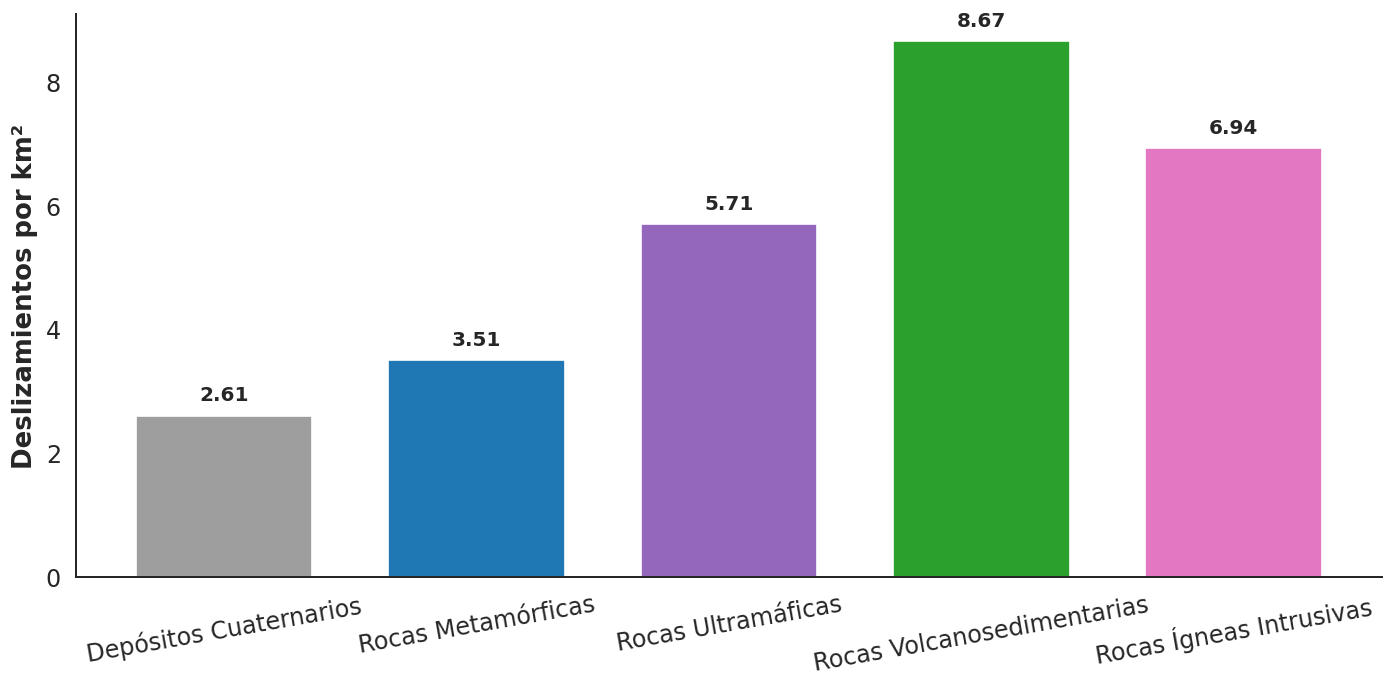

In [9]:
from shapely.ops import unary_union
from matplotlib.ticker import ScalarFormatter

# --- 0) parámetros y utilidades ---
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, unicodedata
from matplotlib.ticker import ScalarFormatter
import geopandas as gpd

def _norm(s):
    if s is None: return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}

orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]

label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",
    "Rocas Metamórficas":         "#1f77b4",
    "Rocas Ultramáficas":         "#9467bd",
    "Rocas Volcanosedimentarias": "#2ca02c",
    "Rocas Ígneas Intrusivas":    "#e377c2",
}

# --- Rutas ------------------------
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/sensores_remotos_amva.geojson"

# ---------- Cargar datos ----------
geo = gpd.read_file(geo_path, encoding="utf-8")
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
# ¡No convertir a 'category' para evitar problemas al agregar!
# geo["Geologia"] = geo["Geologia"].astype("category")
inv = gpd.read_file(inv_path)

# --- 1) Asegurar CRS en metros (clave para el área) ---
if geo.crs is None or geo.crs.is_geographic:
    geo = geo.to_crs(32618)   # Cambia a 3116 si trabajas en MAGNA-SIRGAS oficial
if inv.crs != geo.crs:
    inv = inv.to_crs(geo.crs)

# --- 2) Normalizar y crear etiqueta "bonita" en GEOMETRÍAS y PUNTOS ---
geo_valid = geo.copy()
# Arreglar geometrías simples
geo_valid["geometry"] = geo_valid.buffer(0)

geo_valid["Geologia_norm"]  = geo_valid["Geologia"].apply(_norm)
geo_valid["Geologia_label"] = geo_valid["Geologia_norm"].map(norm_to_label)
# Nos quedamos solo con las clases de interés (para que área y conteo coincidan)
geo_valid = geo_valid.loc[geo_valid["Geologia_label"].isin(orden_labels), ["Geologia_label", "geometry"]].copy()

# --- 3) Área por unidad (disolver por etiqueta bonita y medir km²) ---
# Disolver usando SOLO etiqueta y geometría (no sumar columnas problemáticas)
geo_diss = geo_valid.dissolve(by="Geologia_label", as_index=True)
geo_diss["area_km2"] = geo_diss.geometry.area / 1e6  # m² → km²
df_area = geo_diss[["area_km2"]].reindex(orden_labels)

# --- 4) Conteo de deslizamientos por unidad (usando MISMAS etiquetas) ---
# Asignar a cada punto la unidad geológica mediante sjoin
inv_in = gpd.sjoin(inv, geo_valid, how="inner", predicate="within")

# Conteos y colores
df_counts = (
    inv_in.groupby("Geologia_label")
    .size()
    .reindex(orden_labels, fill_value=0)
    .reset_index()
    .rename(columns={"Geologia_label": "Unidad", 0: "Conteo"})
)
df_counts["Color"] = df_counts["Unidad"].map(label_to_color)

# --- 5) Densidad = Conteo / Área_km² ---
df_den = df_counts.set_index("Unidad").join(df_area, how="left")
df_den["area_km2"] = df_den["area_km2"].replace(0, np.nan)  # evitar división por 0
df_den["Densidad"]  = df_den["Conteo"] / df_den["area_km2"]

# --- 6) Graficar ---
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(df_den.index, df_den["Densidad"], color=df_den["Color"], width=0.7)

# Etiquetas encima
y_offset = (df_den["Densidad"].max() or 0) * 0.02
y_offset = y_offset if y_offset > 0 else 0.05
for bar, d in zip(bars, df_den["Densidad"]):
    if pd.notna(d):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
                f'{d:.2f}', ha='center', va='bottom', fontsize=12, weight='bold')

ax.set_ylabel('Deslizamientos por km²', weight='bold'); ax.set_xlabel('')
ax.spines[['right', 'top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2); ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white'); ax.grid(False); ax.tick_params(axis='x', rotation=10)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='plain', useMathText=True)

plt.tight_layout(); plt.show()

# (Opcional) inspección rápida:
# print(df_den[["Conteo","area_km2","Densidad"]])

### **GRAFICO DE DISPERSIÓN**

In [8]:
#importamos librerias


# cargar datos: tenemos

#Tengo el shapefile de zona de lluvia
zona_lluvia_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/clusters.shp"

#Tengo el shapefile de geologia
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"

#Tengo un archivo .nc con los eventos de lluvia: 
# Ahi tengo los eventos  de lluvia de cada celda del radar dentro del valle de aburrá con las siguiente variables:
# - num_eventos: numero de eventos de lluvia del radar en cada celda
# - intensidad_promedio: intensidad promedio de los eventos de lluvia
# - intensidad_maxima_promedio: intensidad maxima de los eventos de lluvia
# - duracion_promedio: duracion promedio de los eventos de lluvia
# - acumulado_promedio: acumulado promedio de los eventos de lluvia

# ademas  tiene esta informacion de coordenadas:
# Dimensions:                     (lon: 111, lat: 119)
# Coordinates:
#   * lon                         (lon) float64 -75.72 -75.71 ... -75.23 -75.22
#   * lat                         (lat) float64 5.98 5.984 5.989 ... 6.506 6.511

eventos_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/eventos_lluvia_5mm_1horas_2.nc"

#Tengo diferentes archivos .nc con los acumulados promedios de: 1 días, 15 días, 30 días, 60 días y 90 días
acumulados_paths = {
    "1_dia": "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_1d.nc",
    "15_dias": "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_15d.nc",
    "30_dias": "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_30d.nc",
    "60_dias": "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_60d.nc",
    "90_dias": "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_90d.nc"
}

#Cada archivo  .nc tiene la siguiente información:
# <xarray.Dataset>
# Dimensions:  (lon: 111, lat: 119)
# Coordinates:
#   * lon      (lon) float64 -75.72 -75.71 -75.71 -75.7 ... -75.23 -75.23 -75.22
#   * lat      (lat) float64 5.98 5.984 5.989 5.993 ... 6.497 6.502 6.506 6.511
# Data variables:
#     mean     (lon, lat) float64 ...
#     median   (lon, lat) float64 ...
#     min      (lon, lat) float64 ...
#     max      (lon, lat) float64 ...
#     q1       (lon, lat) float64 ...
#     q3       (lon, lat) float64 ...
#     p90      (lon, lat) float64 ...
#     p95      (lon, lat) float64 ...
#     std      (lon, lat) float64 ...
#     var      (lon, lat) float64 ...
# Attributes:
#     title:        Estadísticos de acumulado de 1 días por celda
#     institution:  SIATA / UNAL (plantilla)
#     source:       Archivos CSV por celda (acumulados horarios)
#     history:      Creado con script xarray_estadisticos_acumulados_radar.py

# Por ultimo tengo el shapefile de inventario de deslizamientos
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/sensores_remotos_amva.geojson"





In [2]:
# =========================
# 1) Imports y utilidades
# =========================
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from shapely.geometry import Point
from matplotlib import pyplot as plt
from matplotlib.ticker import ScalarFormatter
import unicodedata

# -------- Normalizador geológico --------
def _norm(s):
    if s is None: return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# -------- Mapeos de geología (color) y zonas (marcador/etiqueta) --------
label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",
    "Rocas Metamórficas":         "#1f77b4",
    "Rocas Ultramáficas":         "#9467bd",
    "Rocas Volcanosedimentarias": "#2ca02c",
    "Rocas Ígneas Intrusivas":    "#e377c2",
}
norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}
orden_labels = list(label_to_color.keys())

marker_por_zona = {1: 's', 2: '^', 3: 'o', 4: 'D', 5: 'P'}
zona_label      = {1: 'Oriente', 2: 'Norte', 3: 'Sur', 4: 'Sap', 5: 'Occidente'}

# -------- Tamaños por densidad (cuartiles por defecto) --------
def _build_size_by_density(df, metric='dens_mm_km2', use_quantiles=True):
    size_levels = [60, 140, 260, 420]
    x = df[metric].replace([np.inf, -np.inf], np.nan).fillna(0)

    if use_quantiles and x.notna().any():
        q1, q2, q3 = x.quantile([0.25, 0.50, 0.75]).values
        bins = [-np.inf, q1, q2, q3, np.inf]
        bin_labels = ['≤ Q1', 'Q1–Q2', 'Q2–Q3', '> Q3']
        display_labels = [
            f"≤ Q1 (≤ {q1:.2f})",
            f"Q1–Q2 ({q1:.2f}–{q2:.2f})",
            f"Q2–Q3 ({q2:.2f}–{q3:.2f})",
            f"> Q3 (> {q3:.2f})"
        ]
    else:
        bins = [-np.inf, 0.02, 0.05, 0.10, np.inf]
        bin_labels = ['≤ 0.02', '0.02–0.05', '0.05–0.10', '> 0.10']
        display_labels = bin_labels[:]

    cats = pd.cut(x, bins=bins, labels=bin_labels, right=True)
    size_map = dict(zip(bin_labels, size_levels))
    sizes = cats.map(size_map).fillna(size_levels[0]).astype(float).values

    return sizes, bin_labels, size_map, display_labels

# =========================
# 2) Entradas
# =========================
zona_lluvia_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/clusters.shp"
geo_path         = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
eventos_path     = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/eventos_lluvia_5mm_1horas_2.nc"
acumulados_paths = {
    "1_dia":  "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_1d.nc",
    "15_dias":"/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_15d.nc",
    "30_dias":"/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_30d.nc",
    "60_dias":"/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_60d.nc",
    "90_dias":"/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_90d.nc"
}
inv_path         = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/sensores_remotos_amva.geojson"

# Nombre de columna de la capa de zonas (¡ajusta aquí si tu shapefile usa otro!)
ZONA_COL = "NOMBRE"       # p.ej. "zona" o "cluster" o "id"
PROJ = 32618            # Usa 3116 si trabajas en MAGNA-SIRGAS oficial


# =========================
# 3) Preparación espacial
# =========================
# Leer zonas y geología
zones = gpd.read_file(zona_lluvia_path)
geo   = gpd.read_file(geo_path, encoding="utf-8")
inv   = gpd.read_file(inv_path)

# Asegurar CRS: proyectar a metros para áreas y distancias
if zones.crs is None or zones.crs.is_geographic:
    zones = zones.to_crs(PROJ)
else:
    zones = zones.to_crs(PROJ)

if geo.crs is None or geo.crs.is_geographic:
    geo = geo.to_crs(PROJ)
else:
    geo = geo.to_crs(PROJ)

if inv.crs != zones.crs:
    inv = inv.to_crs(zones.crs)

# Arreglar geometrías simples
zones["geometry"] = zones.buffer(0)
geo["geometry"]   = geo.buffer(0)

# Normalizar geología y etiquetar “bonito”
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
geo["Geologia_norm"]  = geo["Geologia"].apply(_norm)
geo["Geologia_label"] = geo["Geologia_norm"].map(norm_to_label)

# Filtrar a clases con color definido
geo = geo.loc[geo["Geologia_label"].isin(orden_labels), ["Geologia_label", "geometry"]].copy()

# Validar columna de zona
assert ZONA_COL in zones.columns, f"No encuentro la columna '{ZONA_COL}' en el shapefile de zonas."

# Intersección zona × geología → unidades de análisis
inter = gpd.overlay(geo, zones[[ZONA_COL, "geometry"]], how="intersection")
inter["area_km2"] = inter.geometry.area / 1e6

# =========================
# 4) Convertir grillas .nc a puntos
# =========================
def nc_to_points_df(nc_path, var_rename=None):
    """
    Carga un .nc con dims (lon, lat) y devuelve GeoDataFrame de puntos (centroides de celdas)
    con columnas de variables. var_rename permite renombrar columnas.
    """
    ds = xr.open_dataset(nc_path)
    # Asegurar nombres
    assert "lon" in ds.coords and "lat" in ds.coords, "El .nc debe tener coords 'lon' y 'lat'."
    # Seleccionar variables numéricas
    vars_numeric = [v for v in ds.data_vars if np.issubdtype(ds[v].dtype, np.number)]
    da = ds[vars_numeric].to_array().transpose("lon", "lat", "variable")  # (lon, lat, var)
    # Convertir a DataFrame
    df = ds[vars_numeric].to_dataframe().reset_index()  # columnas: lon, lat, var...
    # Construir geometría en WGS84 y proyectar
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=4326)
    gdf = gdf.to_crs(PROJ)
    # Renombrar si aplica
    if var_rename:
        gdf = gdf.rename(columns=var_rename)
    return gdf

# Cargar eventos (usa nombres exactos en tu .nc)
# Ajusta var_rename si tus variables tienen otros nombres
eventos_gdf = nc_to_points_df(
    eventos_path,
    # var_rename={
    #     # si tus nombres ya coinciden, puedes omitir este dict
    #     # 'num_eventos': 'num_eventos',
    #     # 'intensidad_promedio': 'intensidad_promedio',
    #     # 'intensidad_maxima_promedio': 'intensidad_maxima_promedio',
    #     # 'duracion_promedio': 'duracion_promedio',
    #     # 'acumulado_promedio': 'acumulado_promedio',
    # }
)

# Cargar acumulados (tomamos la variable 'mean' de cada archivo y la renombramos)
acum_list = []
for key, path in acumulados_paths.items():
    ds = xr.open_dataset(path)
    assert "mean" in ds.data_vars, f"El archivo {path} no tiene variable 'mean'."
    df = ds[["mean"]].to_dataframe().reset_index()
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=4326).to_crs(PROJ)
    gdf = gdf.rename(columns={"mean": f"acum_{key}_mean"})
    acum_list.append(gdf[["geometry", f"acum_{key}_mean"]])

# Unir acumulados por geometría (mismo grid → mismo punto)
# Empezamos del eventos_gdf, hacemos joins espaciales exactos por índice (asumimos misma malla y orden)
# Para estar seguros, hacemos un "sjoin_nearest" con un umbral pequeño si hiciera falta.
base = eventos_gdf.copy()
for gdf_a in acum_list:
    # Usar sjoin_nearest por seguridad (si el grid es idéntico, matcheará 1 a 1)
    joined = gpd.sjoin_nearest(gdf_a, base[["geometry"]], how="left", distance_col="dist_join")
    col = [c for c in gdf_a.columns if c.startswith("acum_")][0]
    base[col] = joined[col].values

grid_points = base  # contiene eventos + acumulados por punto (en CRS PROJ)

# =========================
# 5) Agregación por intersección (zona×geología)
# =========================
# a) Asignar cada punto de grid a una intersección (zona×geo)
pts_in = gpd.sjoin(grid_points, inter[[ZONA_COL, "Geologia_label", "geometry"]], how="inner", predicate="within")

# b) Promedios por (zona, geología)
num_cols = [c for c in pts_in.columns if c not in ["index_right", ZONA_COL, "Geologia_label", "geometry"]]
agg_rain = pts_in.groupby([ZONA_COL, "Geologia_label"])[num_cols].mean().reset_index()

# c) Área por (zona, geología)
areas = inter.groupby([ZONA_COL, "Geologia_label"], as_index=False)["area_km2"].sum()

# d) Conteo de deslizamientos y densidad
inv_in = gpd.sjoin(inv, inter[[ZONA_COL, "Geologia_label", "geometry"]], how="inner", predicate="within")
land_counts = inv_in.groupby([ZONA_COL, "Geologia_label"]).size().reset_index(name="N_desliz")

# Merge maestro
df = (
    agg_rain
    .merge(areas, on=[ZONA_COL, "Geologia_label"], how="left")
    .merge(land_counts, on=[ZONA_COL, "Geologia_label"], how="left")
)

df["N_desliz"] = df["N_desliz"].fillna(0).astype(int)
df["dens_mm_km2"] = np.where(df["area_km2"] > 0, df["N_desliz"] / df["area_km2"], 0.0)
df["zona_name"]   = df[ZONA_COL].map(zona_label)
df["color"]       = df["Geologia_label"].map(label_to_color)

In [7]:
#guardar df
df.to_csv("analisis_zona_geologia_rainfall_landslides.csv", index=False)

In [36]:
zones

,NOMBRE,AREA_m2,PERIMETRO_,Cluster,geometry
0,Norte,2.062969e+08,82614.894347,2,"POLYGON ((436829.664 693139.954, 436829.657 69..."
1,Occidente,3.754912e+08,108927.952274,5,"POLYGON ((426358.596 704159.209, 426362.640 70..."
2,Sur,1.347485e+08,57144.130934,3,"POLYGON ((428064.078 686275.084, 428120.144 68..."
3,Oriente,3.754912e+08,108927.952274,1,"POLYGON ((444732.439 695113.502, 444757.964 69..."
4,Sap,3.754912e+08,108927.952274,4,"POLYGON ((421705.710 691805.672, 421785.299 69..."


In [3]:
# geo["Geologia_norm"]  = geo["Geologia"].apply(_norm)
# geo["Geologia_label"] = geo["Geologia_norm"].map(norm_to_label)

print(geo["Geologia_label"].unique())
print(geo["Geologia_label"].unique())

['Depósitos Cuaternarios' 'Rocas Volcanosedimentarias'
 'Rocas Metamórficas' 'Rocas Ultramáficas' 'Rocas Ígneas Intrusivas']
['Depósitos Cuaternarios' 'Rocas Volcanosedimentarias'
 'Rocas Metamórficas' 'Rocas Ultramáficas' 'Rocas Ígneas Intrusivas']


Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']
Únicos en df_final[NOMBRE]: ['Norte' 'Occidente' 'Oriente' 'Sap' 'Sur']


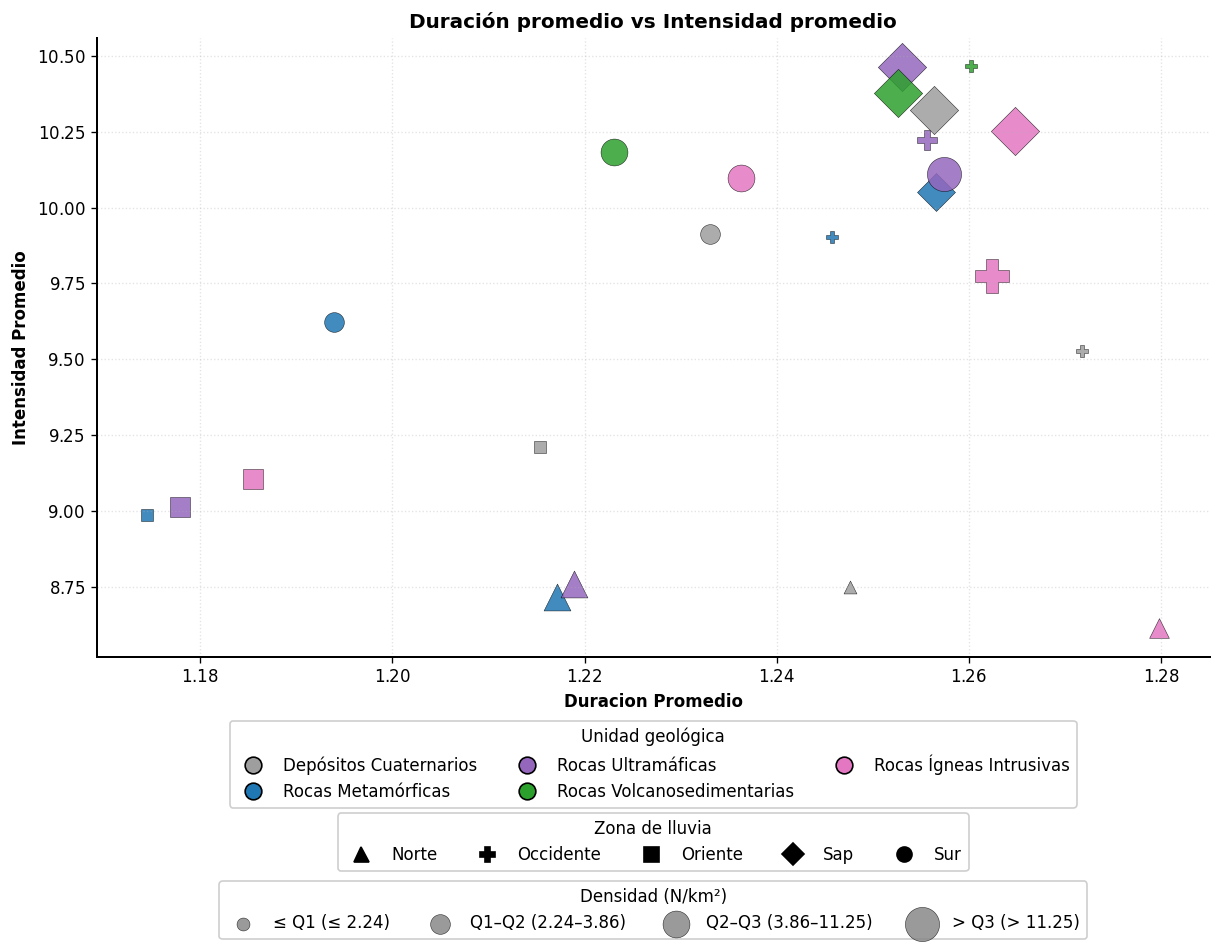

<Axes: title={'center': 'Duración promedio vs Intensidad promedio'}, xlabel='Duracion Promedio', ylabel='Intensidad Promedio'>

In [3]:
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D


# Diccionarios “oficiales”
marker_por_zona = {1: 's', 2: '^', 3: 'o', 4: 'D', 5: 'P'}
zona_label      = {1: 'Oriente', 2: 'Norte', 3: 'Sur', 4: 'SAP', 5: 'Occidente'}


def _build_markers_auto(df, zona_col):
    """
    Devuelve:
      - markers_map: dict valor_de_zona -> marcador
      - legend_handles: handles para la leyenda de zonas
    Si zona_col coincide con los IDs {1..5}, usa marker_por_zona.
    Si viene con nombres (p. ej. 'Norte'), mapea nombres -> IDs conocidos si coinciden,
    de lo contrario asigna marcadores cíclicamente.
    """
    valores = pd.unique(df[zona_col])
    valores = [v for v in valores if pd.notna(v)]

    # Caso 1: valores son enteros y están en el dict estándar
    if pd.api.types.is_integer_dtype(df[zona_col]) and set(valores).issubset(set(marker_por_zona.keys())):
        markers_map = {v: marker_por_zona[int(v)] for v in valores}
        legend_handles = [
            Line2D([], [], marker=marker_por_zona[i], color='k', linestyle='None',
                   label=zona_label.get(i, str(i)), markersize=9)
            for i in sorted(valores)
        ]
        return markers_map, legend_handles

    # Caso 2: vienen como nombres (intenta mapearlos a IDs oficiales)
    inv_zona_label = {v: k for k, v in zona_label.items()}  # 'Norte' -> 2, etc.
    markers_map = {}
    used_ids = set()
    free_ids = [k for k in marker_por_zona.keys()]

    for v in valores:
        if v in inv_zona_label:
            zid = inv_zona_label[v]
            markers_map[v] = marker_por_zona[zid]
            used_ids.add(zid)
        else:
            # asigna marcadores libres cíclicamente
            zid = free_ids[len(markers_map) % len(free_ids)]
            markers_map[v] = marker_por_zona[zid]

    # Leyenda con los nombres reales presentes
    legend_handles = [
        Line2D([], [], marker=markers_map[v], color='k', linestyle='None',
               label=str(v), markersize=9)
        for v in valores
    ]
    return markers_map, legend_handles


def scatter_lluvia(
    df,
    xvar,
    yvar,
    size_metric="dens_mm_km2",
    use_quantiles=True,
    title=None,
    figsize=(10, 8),
    alpha=0.85,
    edgecolor="k",
    lw=0.3,
    ZONA_COL="zona",
):
    """
    Grafica X vs Y:
      - Color = unidad geológica (label_to_color)
      - Marcador = zona (auto-detecta si es ID o nombre)
      - Tamaño = densidad (cuartiles o umbrales fijos)
    """
    # 0) Validaciones básicas
    if xvar not in df.columns or yvar not in df.columns:
        raise ValueError(f"xvar/yvar no existen en df. Recibí xvar='{xvar}', yvar='{yvar}'")

    df_plot = df.copy()

    # 1) Limpiar/asegurar numéricos en x/y
    df_plot[xvar] = pd.to_numeric(df_plot[xvar], errors="coerce")
    df_plot[yvar] = pd.to_numeric(df_plot[yvar], errors="coerce")
    df_plot = df_plot.dropna(subset=[xvar, yvar])

    if df_plot.empty:
        print("¡Advertencia! No hay datos válidos para graficar (NaNs en x/y o filtros previos).")
        fig, ax = plt.subplots(figsize=figsize, dpi=120)
        ax.set_title(title or f"{xvar} vs {yvar}")
        return ax

    # 2) Tamaños por densidad (como Series alineada por índice)
    sizes_arr, bin_labels, size_map, display_labels = _build_size_by_density(
        df_plot, metric=size_metric, use_quantiles=use_quantiles
    )
    sizes = pd.Series(sizes_arr, index=df_plot.index)

    # 3) Marcadores por zona (auto)
    markers_map, marker_handles = _build_markers_auto(df_plot, ZONA_COL)

    # 4) Figura (reservamos espacio inferior para leyendas con 'rect')
    fig, ax = plt.subplots(figsize=figsize, dpi=120)
    # deja 28% inferior (ajusta si necesitas más/menos)
    fig.tight_layout(rect=(0, 0.28, 1, 1))

    # 5) Pintar por zona y geología
    plotted = False
    for zona_val, mk in markers_map.items():
        sel_z = df_plot[df_plot[ZONA_COL] == zona_val]
        if sel_z.empty:
            continue
        for geo_lab, color in label_to_color.items():
            sel = sel_z[sel_z["Geologia_label"] == geo_lab]
            if sel.empty:
                continue
            ax.scatter(
                sel[xvar], sel[yvar],
                s=sizes.loc[sel.index].values,
                c=color,
                marker=mk,
                alpha=alpha,
                edgecolors=edgecolor,
                linewidths=lw,
            )
            plotted = True

    if not plotted:
        print("No se pintó ningún punto. Revisa valores de zona y Geologia_label.")
        print("Únicos en df[ZONA_COL]:", pd.unique(df[ZONA_COL]))
        print("Únicos en df['Geologia_label']:", pd.unique(df["Geologia_label"]))
        return ax

    # 6) Ejes y estilo
    ax.set_xlabel(xvar.replace("_", " ").title(), weight='bold')
    ax.set_ylabel(yvar.replace("_", " ").title(), weight='bold')
    if title:
        ax.set_title(title, weight='bold')

    ax.spines[['right', 'top']].set_visible(False)
    ax.spines['left'].set_linewidth(1.2); ax.spines['bottom'].set_linewidth(1.2)
    ax.set_facecolor('white'); ax.grid(True, ls=":", alpha=0.35)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='both', style='plain', useMathText=True)

    # 7) Leyendas en la parte inferior (3 bloques)
    # Colores (geología)
    color_handles = [
        Line2D([], [], marker='o', color='none', markerfacecolor=col, markeredgecolor='k',
               markersize=10, label=lab) for lab, col in label_to_color.items()
    ]
    # Marcadores (zonas) - ya construidos por _build_markers_auto
    # Tamaños (densidad)
    size_handles = [
        plt.scatter([], [], s=size_map[bl], c="#888888", alpha=0.85,
                    edgecolors="k", linewidths=0.3, label=display_labels[i])
        for i, bl in enumerate(bin_labels)
    ]

    # Colocación en banda inferior
    leg1 = ax.legend(handles=color_handles, title="Unidad geológica",
                     loc="upper center", bbox_to_anchor=(0.50, -0.09),
                     ncol=3, frameon=True, fancybox=True, framealpha=0.95)
    ax.add_artist(leg1)

    leg2 = ax.legend(handles=marker_handles, title="Zona de lluvia",
                     loc="upper center", bbox_to_anchor=(0.50, -0.24),
                     ncol=max(1, len(marker_handles)), frameon=True, fancybox=True, framealpha=0.95)
    ax.add_artist(leg2)

    leg3 = ax.legend(handles=size_handles, title="Densidad (N/km²)",
                     loc="upper center", bbox_to_anchor=(0.50, -0.35),
                     ncol=len(size_handles), frameon=True, fancybox=True, framealpha=0.95)

    plt.show()
    return ax

# =========================
# 7) DataFrame final y ejemplos de uso
# =========================
# DataFrame ordenado
cols_front = [ZONA_COL, "Geologia_label", "area_km2", "N_desliz", "dens_mm_km2"]
rain_cols = [c for c in df.columns if c.startswith(("intensidad","duracion","acumulado","num_eventos","acum_"))]
df_final = df[cols_front + rain_cols].sort_values([ZONA_COL, "Geologia_label"]).reset_index(drop=True)

print("Columnas disponibles para graficar X/Y:\n", rain_cols)

# Ejemplos de gráficos (descomenta el que necesites):
# 1) Duración vs Intensidad
# Verifica cómo viene tu columna de zona
print("Únicos en df_final[NOMBRE]:", df_final["NOMBRE"].unique())

# Ejemplo
scatter_lluvia(
    df_final,
    xvar="duracion_promedio",
    yvar="intensidad_promedio",
    title="Duración promedio vs Intensidad promedio",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)

# 2) Acumulado 1 día vs Intensidad
# scatter_lluvia(df_final, xvar="acum_1_dia_mean", yvar="intensidad_promedio",
#                title="Acumulado 1 día (mean) vs Intensidad promedio")

# 3) Acumulado 90 días vs Acumulado 1 día
# scatter_lluvia(df_final, xvar="acum_90_dias_mean", yvar="acum_1_dia_mean",
#                title="Acumulado 90 días (mean) vs Acumulado 1 día (mean)")

# df_final  # <- inspecciona la tabla final si quieres

Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


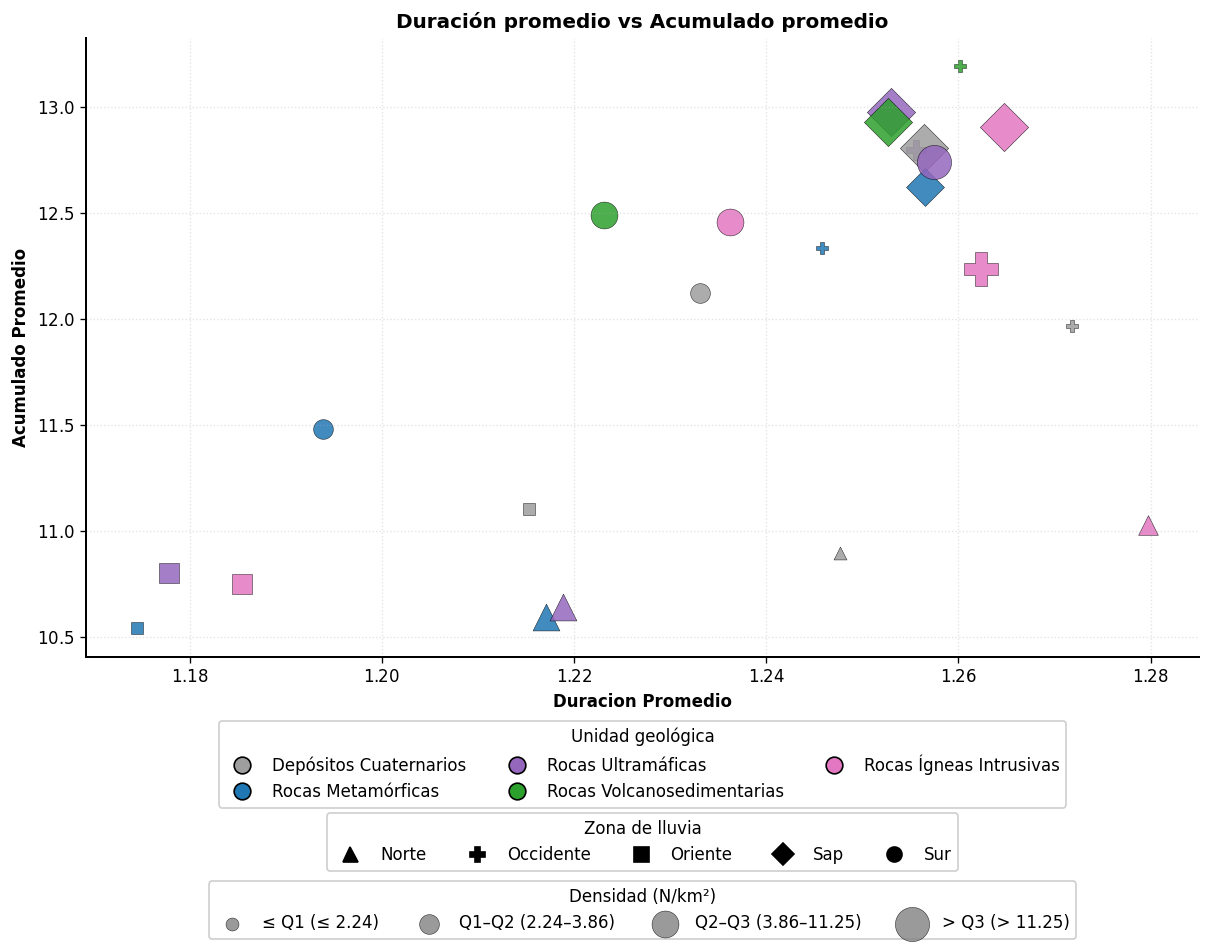

In [8]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="duracion_promedio",
    yvar="acumulado_promedio",
    title="Duración promedio vs Acumulado promedio",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)

Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


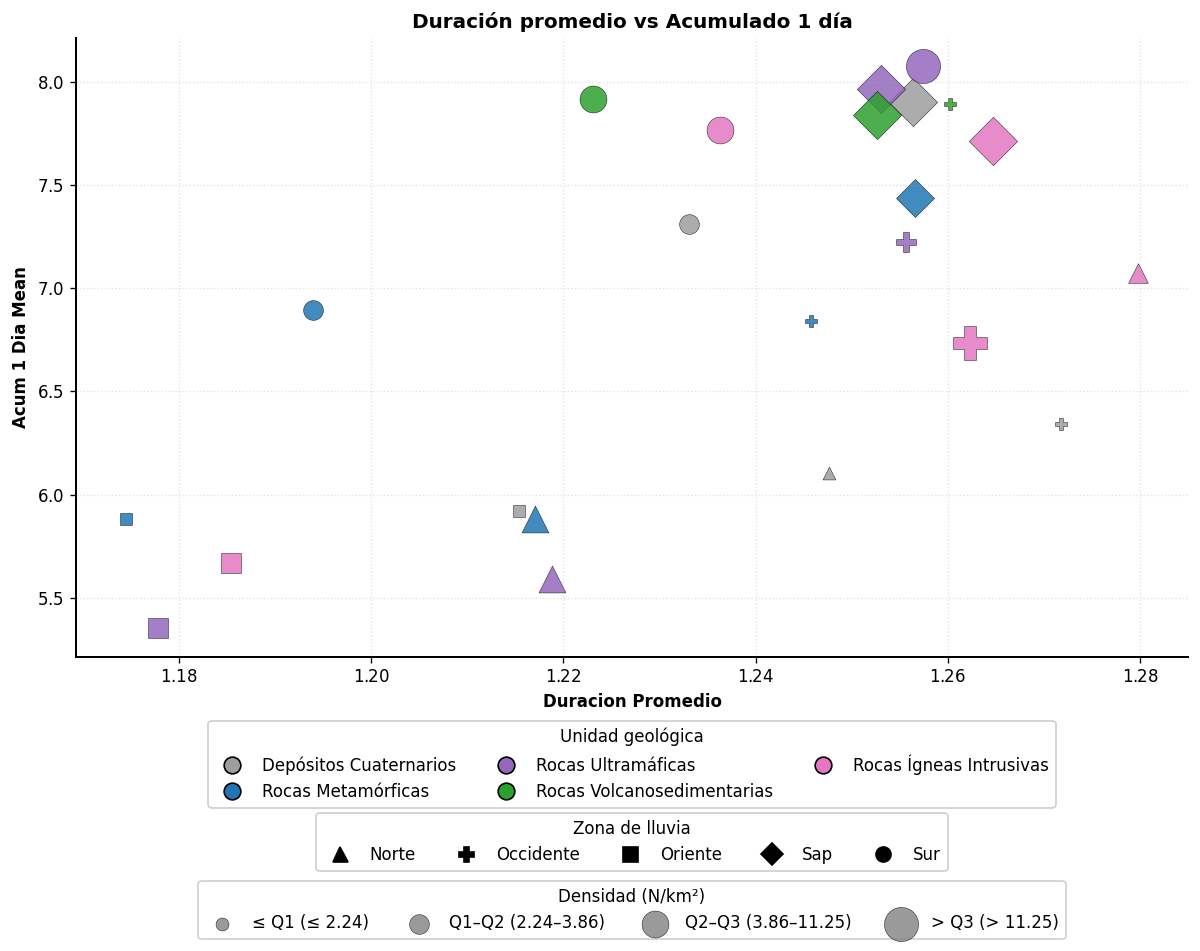

In [9]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="duracion_promedio",
    yvar="acum_1_dia_mean",
    title="Duración promedio vs Acumulado 1 día",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)

Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


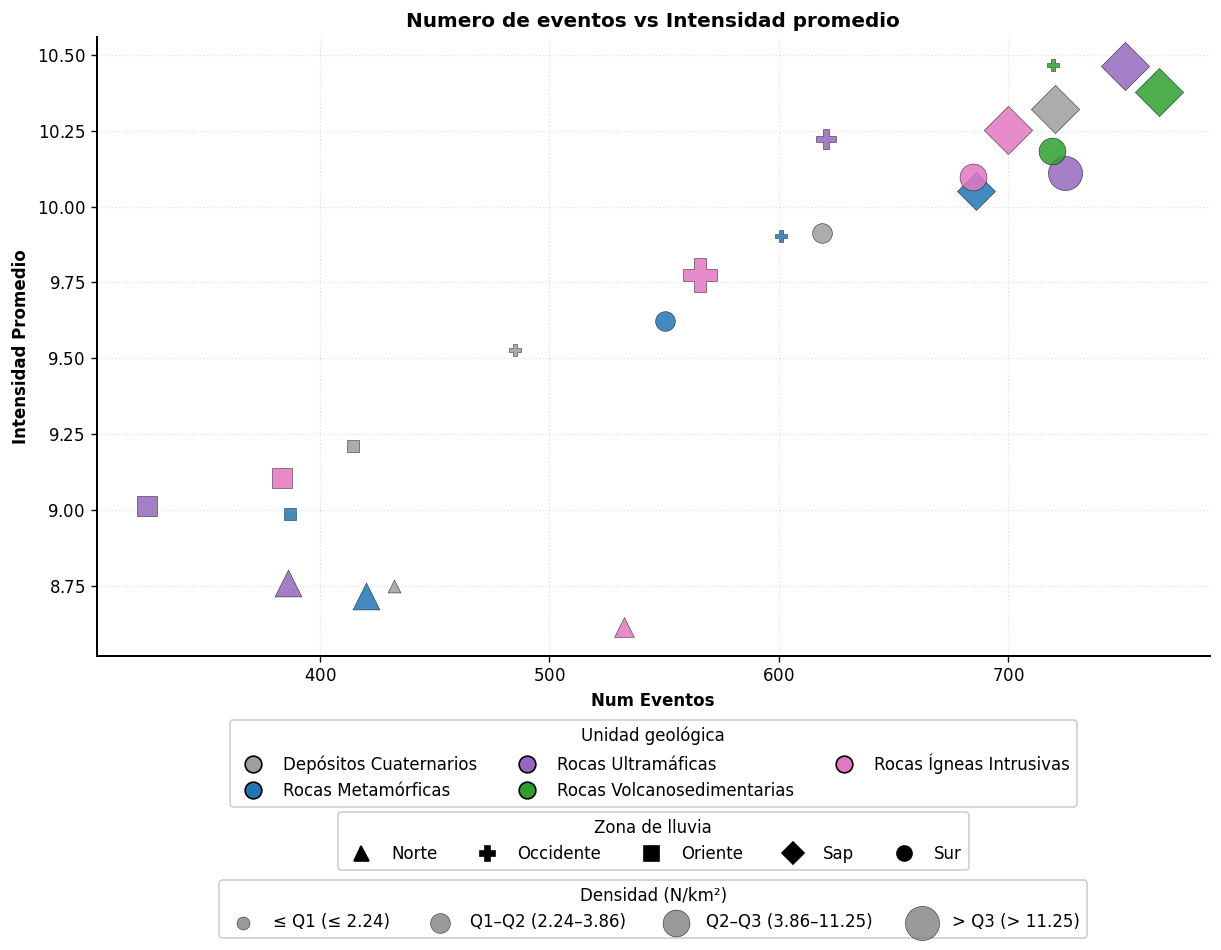

In [5]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="num_eventos",
    yvar="intensidad_promedio",
    title="Numero de eventos vs Intensidad promedio",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)


Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


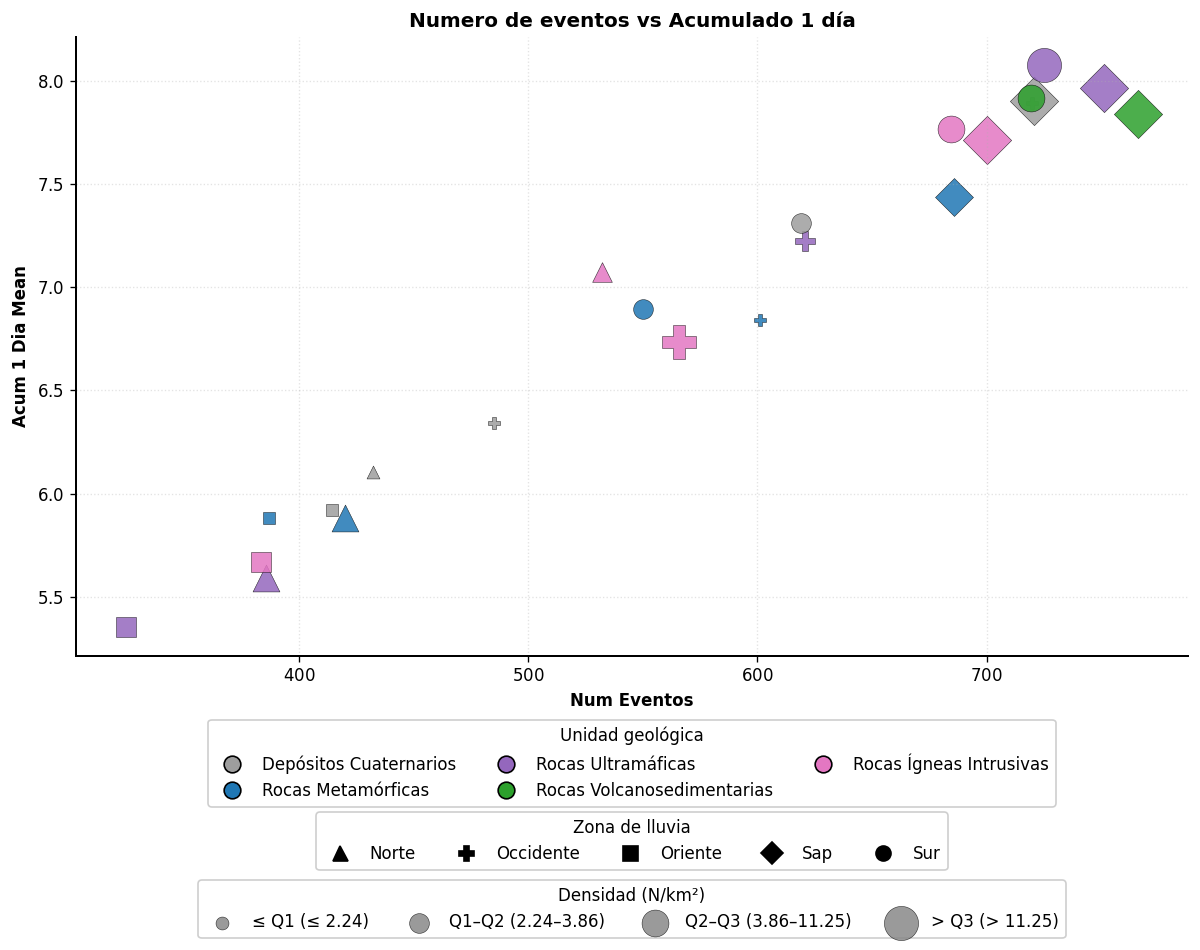

In [10]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="num_eventos",
    yvar="acum_1_dia_mean",
    title="Numero de eventos vs Acumulado 1 día",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)


Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


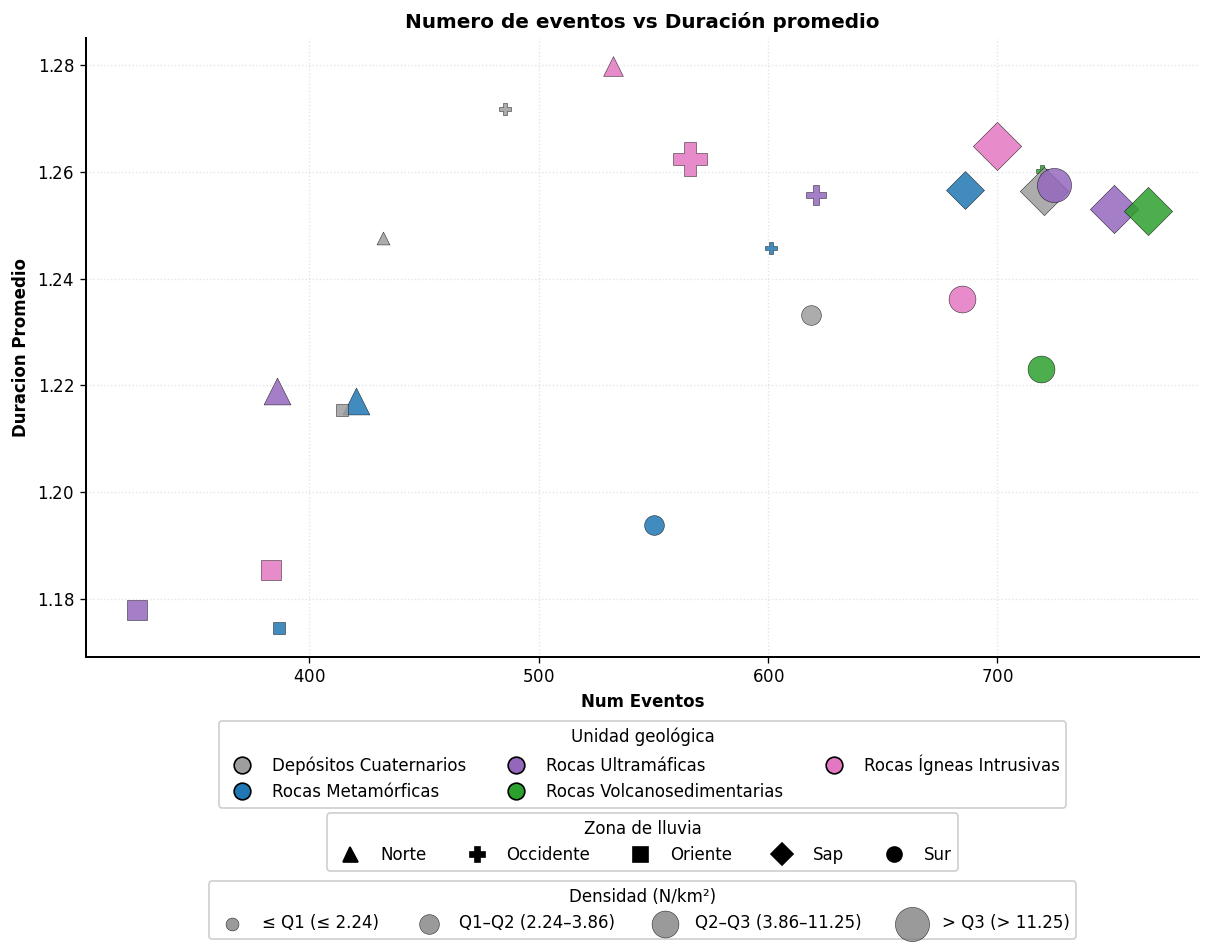

In [6]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="num_eventos",
    yvar="duracion_promedio",
    title="Numero de eventos vs Duración promedio",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)


Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


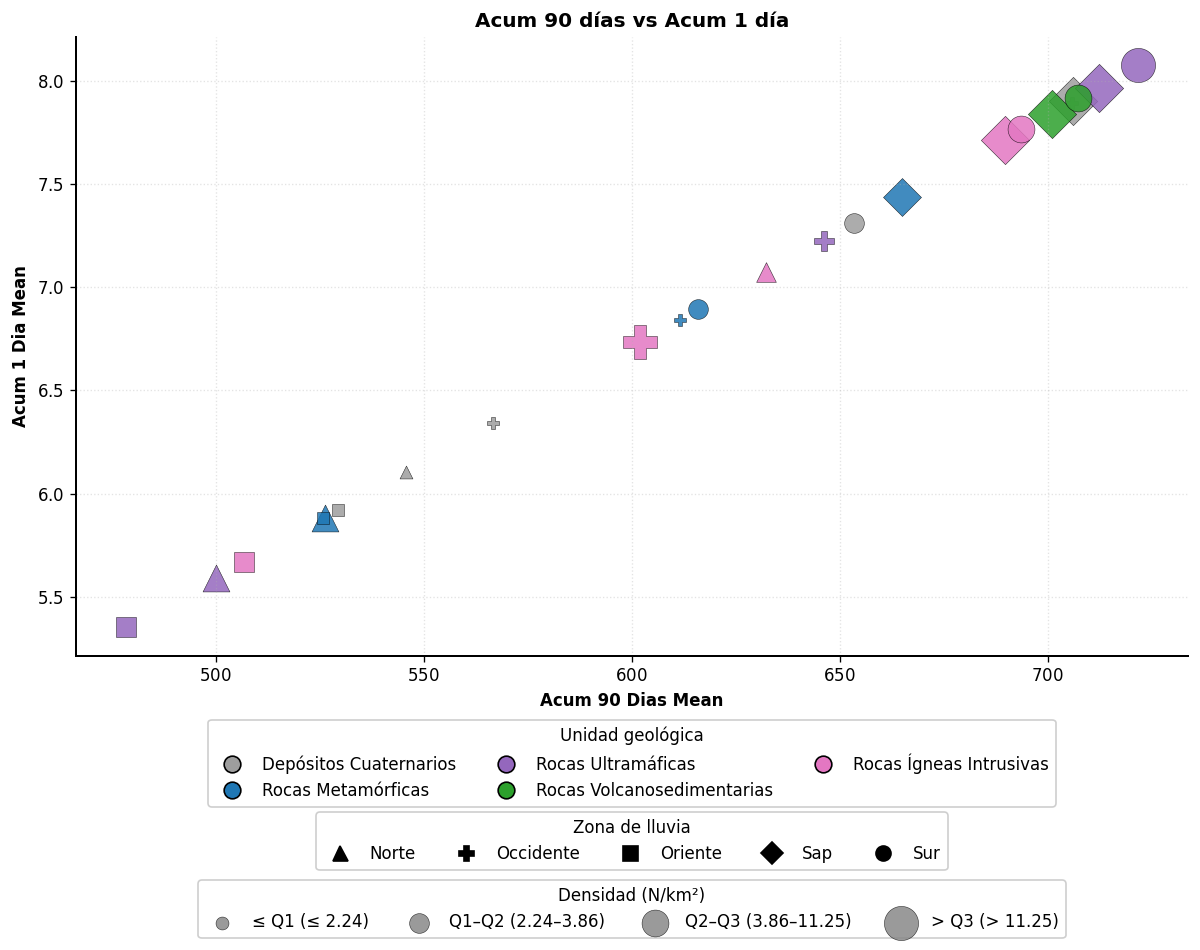

In [7]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="acum_90_dias_mean",
    yvar="acum_1_dia_mean",
    title="Acum 90 días vs Acum 1 día",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)

Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


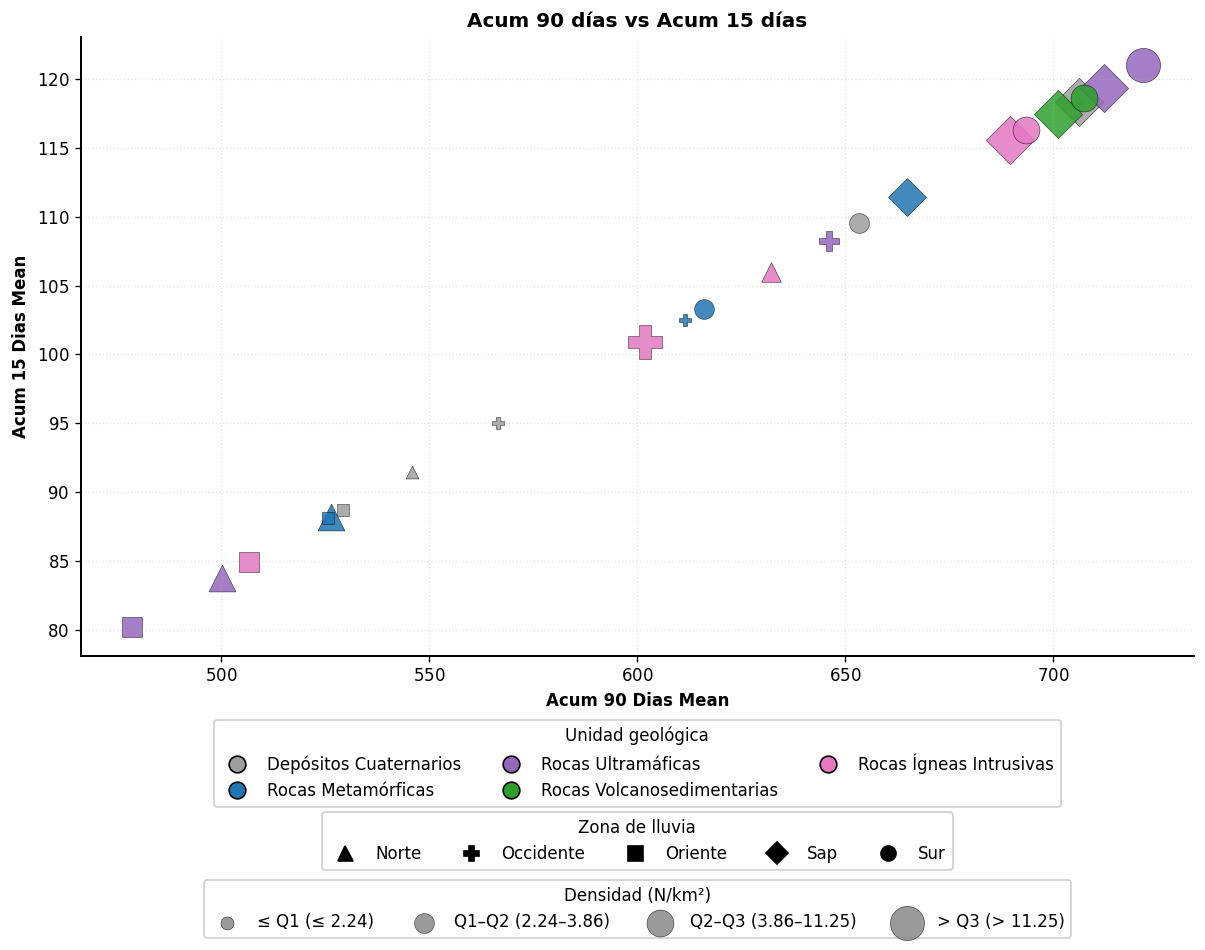

In [12]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="acum_90_dias_mean",
    yvar="acum_15_dias_mean",
    title="Acum 90 días vs Acum 15 días",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)

### **GEOLOGÍA Y SLOPE UNITS**

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Rutas
slope_units_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/slope_units_analisis.shp"
geologia_path     = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"

# Leer
su  = gpd.read_file(slope_units_path)
geo = gpd.read_file(geologia_path)

# Limpieza básica
su  = su[~su.geometry.is_empty & su.geometry.notnull()].copy()
geo = geo[~geo.geometry.is_empty & geo.geometry.notnull()].copy()

# Asegurar CRS definido
if su.crs is None:
    raise ValueError("El shapefile de slope units no tiene CRS. Asigna su.crs antes de continuar.")
if geo.crs is None:
    raise ValueError("El shapefile de geología no tiene CRS. Asigna geo.crs antes de continuar.")

# Reproyección a un CRS métrico (MAGNA-SIRGAS / Colombia Bogotá)
TARGET_CRS = "EPSG:3116"
if su.crs.to_string() != TARGET_CRS:
    su = su.to_crs(TARGET_CRS)
if geo.crs.to_string() != TARGET_CRS:
    geo = geo.to_crs(TARGET_CRS)

# Asegurar un ID único para cada slope unit
if "su_id" not in su.columns:
    su = su.reset_index(drop=False).rename(columns={"index":"su_id"})


In [2]:
# Intersección geométrica
inter = gpd.overlay(su[["su_id","geometry"]], geo[["Geologia","geometry"]], how="intersection")

# Área de la porción intersectada
inter["area_m2"] = inter.geometry.area

# Elegir, para cada su_id, la geología con mayor área de intersección
idx = (inter.groupby("su_id")["area_m2"].idxmax()).dropna()
dominante = inter.loc[idx, ["su_id", "Geologia"]].rename(columns={"Geologia":"Geologia"})

# Anexar columna 'Geologia' a las slope units
su = su.merge(dominante, on="su_id", how="left")

# Comprobar cuántas quedaron sin geología (poco común; serían fuera del polígono geológico)
faltantes = su["Geologia"].isna().sum()
print(f"Slope units sin geología asignada: {faltantes}")


Slope units sin geología asignada: 0


In [3]:
# Área por SU (km²)
su["area_km2"] = su.geometry.area / 1e6

# Evitar divisiones por cero
su["area_km2"] = su["area_km2"].replace({0: np.nan})

# Densidad de deslizamientos (n_mm por km²)
if "n_mm" not in su.columns:
    raise ValueError("No encuentro la columna 'n_mm' en slope units.")
if "cluster4" not in su.columns:
    raise ValueError("No encuentro la columna 'cluster4' en slope units.")

su["dens_mm_km2"] = su["n_mm"] / su["area_km2"]


grp = (su
       .dropna(subset=["Geologia","cluster4","area_km2"])
       .groupby(["cluster4","Geologia"])
       .agg(
           total_deslizamientos = ("n_mm","sum"),
           total_area_km2       = ("area_km2","sum"),
           densidad_media       = ("dens_mm_km2","mean"),
           n_su                 = ("su_id","count")
       )
       .reset_index()
      )

grp["densidad_global"] = grp["total_deslizamientos"] / grp["total_area_km2"]

# Orden rápido por mayor densidad global
grp_sorted = grp.sort_values("densidad_global", ascending=False)
grp_sorted.head(10)


salida_su = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/slope_units_analisis_con_geo.geojson"
su.to_file(salida_su, driver='GeoJSON')
print("Guardado:", salida_su)


Guardado: /home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/slope_units_analisis_con_geo.geojson


/tmp/ipykernel_2664407/1375717732.py:62: UserWarning: Glyph 141 (\x8d) missing from current font.
  plt.tight_layout()
/home/oisanchezp/geo_env/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 141 (\x8d) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


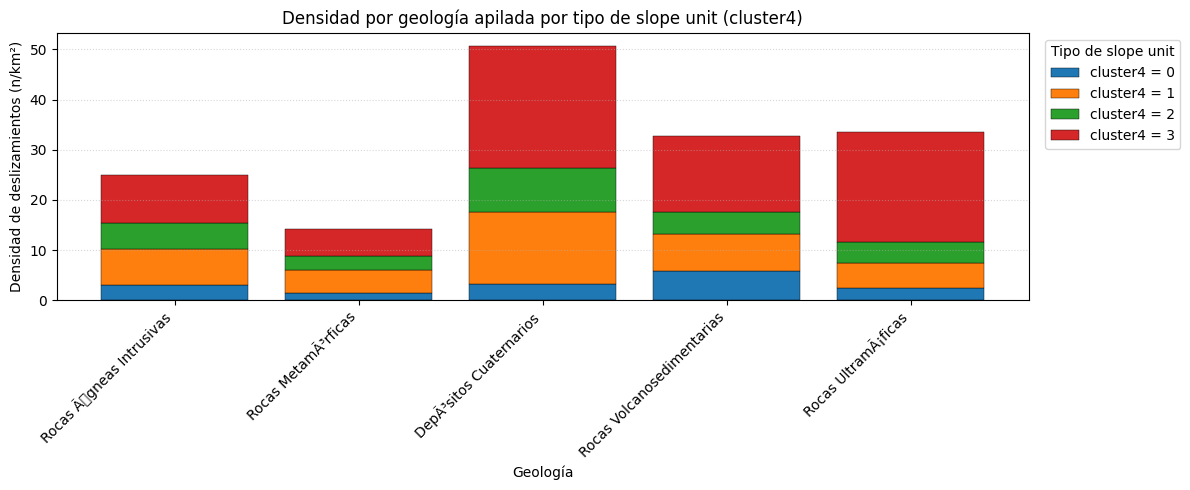

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Si ya tienes 'grp' del paso anterior, puedes saltarte este bloque de recomputo ---
if "grp" not in globals():
    # Recalcular agregados (por si abriste una nueva sesión)
    assert all(c in su.columns for c in ["Geologia","cluster4","n_mm","area_km2"]), "Faltan columnas en 'su'"
    grp = (su.dropna(subset=["Geologia","cluster4","area_km2"])
             .groupby(["cluster4","Geologia"])
             .agg(total_deslizamientos=("n_mm","sum"),
                  total_area_km2=("area_km2","sum"))
             .reset_index())
    grp["densidad_global"] = grp["total_deslizamientos"] / grp["total_area_km2"]

# Orden opcional de geologías: por área total (más extensas primero) o por densidad total
orden_por = "area"   # "area" o "densidad"
topN = None          # pon un entero (p.ej., 15) si quieres recortar a las más relevantes

# Área total por geología
area_por_geo = (grp.groupby("Geologia")["total_area_km2"].sum()
                  .sort_values(ascending=False))

# Densidad total por geología (suma de densidades por cluster; solo para ordenar)
dens_total_por_geo = (grp.groupby("Geologia")["densidad_global"].sum()
                        .sort_values(ascending=False))

if orden_por == "area":
    geos_orden = area_por_geo.index
else:
    geos_orden = dens_total_por_geo.index

if topN is not None:
    geos_orden = geos_orden[:topN]

# Pivot: filas = geología, columnas = cluster4, valores = densidad_global
plot_df = (grp[grp["Geologia"].isin(geos_orden)]
             .pivot_table(index="Geologia", columns="cluster4", values="densidad_global", aggfunc="sum")
             .reindex(index=geos_orden))

# Asegurar columnas en orden 0–3 aunque falte alguna
cols = [c for c in [0,1,2,3] if c in plot_df.columns]
plot_df = plot_df[cols].fillna(0.0)

# --- Gráfico de barras apiladas ---
fig, ax = plt.subplots(figsize=(12, 5))

bottom = np.zeros(len(plot_df))
x = np.arange(len(plot_df))

for c in cols:
    ax.bar(x, plot_df[c].values, bottom=bottom, label=f"cluster4 = {c}", edgecolor="k", linewidth=0.3)
    bottom += plot_df[c].values

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=45, ha="right")
ax.set_ylabel("Densidad de deslizamientos (n/km²)")
ax.set_xlabel("Geología")
ax.set_title("Densidad por geología apilada por tipo de slope unit (cluster4)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), title="Tipo de slope unit")
ax.grid(axis="y", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()


# **ANÁLISIS DE GEOLOGÍA CON INVENTARIO GEOHAZARDS**

### **MAPA GEOLÓGICO GENERAL DEL VALLE DE ABURRÁ CON EL INVENTARIO DE GEOHAZARDS**

Puntos antes: 2768 | Puntos dentro de geología: 2749


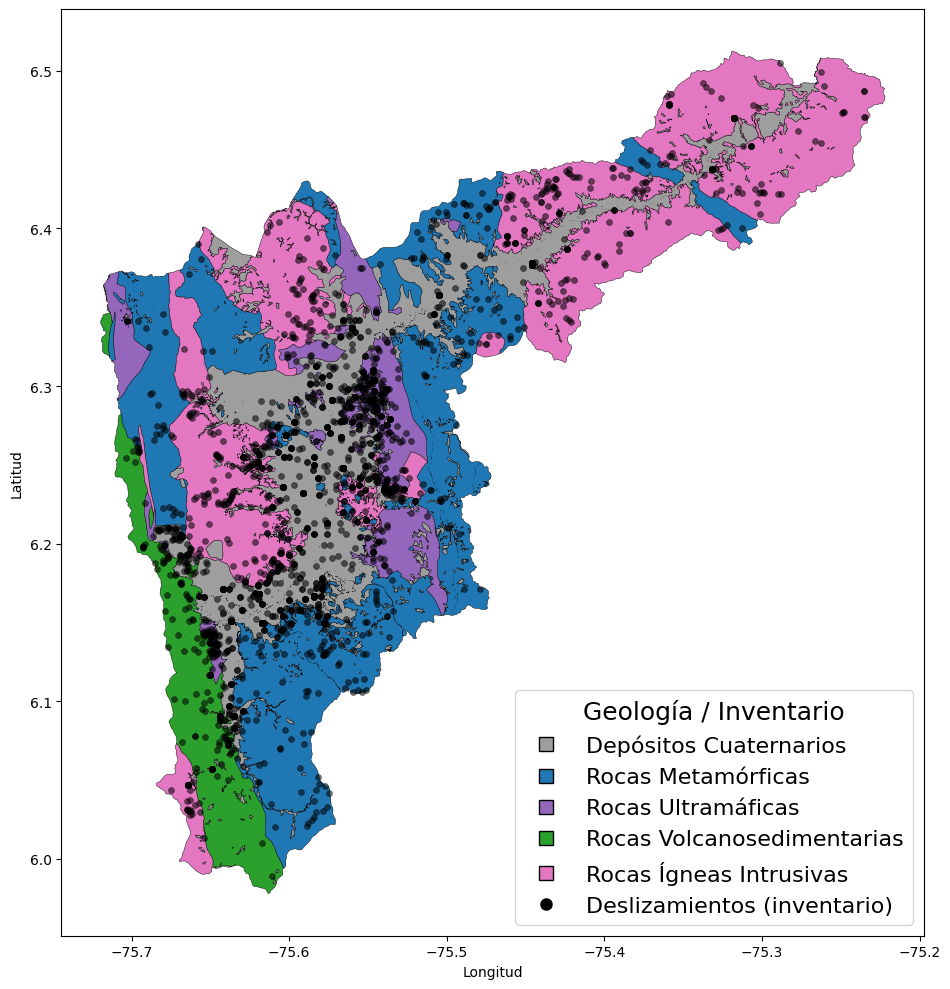

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- Rutas ---
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/Geohazard_RS.gpkg"

path_dagrd = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/inventory_GEOHAZARDS_20240824.csv"

# --- 1) Cargar geología ---
geo = gpd.read_file(geo_path, encoding="utf-8")

geo = gpd.read_file(geo_path, encoding="utf-8")
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
geo["Geologia"] = geo["Geologia"].astype("category")

# (Opcional pero recomendado para escala/norte correctos)
# geo = geo.to_crs(32618)  # UTM 18N Valle de Aburrá

# --- 2) Cargar inventario de deslizamientos ---
inv = gpd.read_file(inv_path)

# Si el inventario no tiene CRS, asumimos el mismo que la geología (ajústalo si sabes el EPSG exacto del inventario)
if inv.crs is None and geo.crs is not None:
    inv.set_crs(geo.crs, inplace=True)

# Reproyectar al CRS de geología si difieren
if geo.crs is not None and inv.crs is not None and inv.crs != geo.crs:
    inv = inv.to_crs(geo.crs)

# --- 2.b) QUEDARSE SOLO CON LOS PUNTOS DENTRO DE GEOLOGÍA ---
inv_before = len(inv)

# Asegura geometrías válidas (evita topologías raras)
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)  # o usa shapely.make_valid si tienes Shapely 2.x

# Recortar (clip) los puntos del inventario al polígono de geología
inv = gpd.clip(inv, geo_valid)

print(f"Puntos antes: {inv_before} | Puntos dentro de geología: {len(inv)}")
# Si por alguna razón el inventario viene en polígonos/líneas y quieres puntos:
# inv = inv.copy()
# inv["geometry"] = inv.geometry.centroid

# --- 3) Graficar ---
import unicodedata
from matplotlib.lines import Line2D

# --- Normalizador (sin tildes, minúsculas) ---
def _norm(s):
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# --- Mapa de colores por categoría (claves normalizadas) ---
color_map_norm = {
    "depositos cuaternarios":        "#9e9e9e",  # gris
    "rocas metamorficas":            "#1f77b4",  # azul
    "rocas ultramaficas":            "#9467bd",  # morado
    "rocas volcanosedimentarias":    "#2ca02c",  # verde
    "rocas igneas intrusivas":       "#e377c2",  # rosado
}


# Mejor: que 'Geologia' NO sea categoría durante el mapeo
geo["Geologia"] = geo["Geologia"].astype(str)

geo["Geologia_norm"] = geo["Geologia"].apply(_norm)
s = geo["Geologia_norm"].map(color_map_norm)

geo["fillcolor"] = s.astype("object").fillna("#cccccc")
# --- Graficar con colores fijos ---
fig, ax = plt.subplots(figsize=(10, 10))

# Geología
geo.plot(ax=ax, facecolor=geo["fillcolor"], edgecolor="black", linewidth=0.3)

# Inventario (como ya lo tienes)
inv.plot(ax=ax, marker="o", color="black",
         edgecolor="black", linewidth=0.5,
         markersize=18, alpha=0.55, zorder=5)

#ax.set_title("Mapa de Unidades Geológicas + Inventario de Deslizamientos", fontsize=14)
ax.set_xlabel("Longitud" if geo.crs is None or (geo.crs and geo.crs.is_geographic) else "X (m)")
ax.set_ylabel("Latitud" if geo.crs is None or (geo.crs and geo.crs.is_geographic) else "Y (m)")
ax.set_aspect("equal")

# --- Leyenda manual en orden deseado + deslizamientos ---
orden_legenda = [
    ("Depósitos Cuaternarios",      "#9e9e9e"),
    ("Rocas Metamórficas",          "#1f77b4"),
    ("Rocas Ultramáficas",          "#9467bd"),
    ("Rocas Volcanosedimentarias",  "#2ca02c"),
    ("Rocas Ígneas Intrusivas",     "#e377c2"),
]

handles_geo = [Line2D([0], [0], marker='s', linestyle='',
                      markerfacecolor=c, markeredgecolor='black',
                      markersize=10, label=lab) for lab, c in orden_legenda]

handle_inv = Line2D([0], [0], marker='o', linestyle='', markerfacecolor='black',
                    markeredgecolor='black', markersize=8, label='Deslizamientos (inventario)')

labels_geo = [lab for lab, _ in orden_legenda]
labels = labels_geo + ["Deslizamientos (inventario)"]

ax.legend(handles=handles_geo + [handle_inv],
          labels=labels,
          title="Geología / Inventario",
          loc="lower right", frameon=True, fontsize=16, title_fontsize=18)


plt.tight_layout()
plt.show()

/home/oisanchezp/geo_env/lib/python3.8/site-packages/geopandas/array.py:968: RuntimeWarning: All-NaN slice encountered
  np.nanmin(b[:, 0]),  # minx
/home/oisanchezp/geo_env/lib/python3.8/site-packages/geopandas/array.py:969: RuntimeWarning: All-NaN slice encountered
  np.nanmin(b[:, 1]),  # miny
/home/oisanchezp/geo_env/lib/python3.8/site-packages/geopandas/array.py:970: RuntimeWarning: All-NaN slice encountered
  np.nanmax(b[:, 2]),  # maxx
/home/oisanchezp/geo_env/lib/python3.8/site-packages/geopandas/array.py:971: RuntimeWarning: All-NaN slice encountered
  np.nanmax(b[:, 3]),  # maxy


Puntos antes: 1751 | Puntos dentro de geología: 0


ValueError: aspect must be finite and positive 

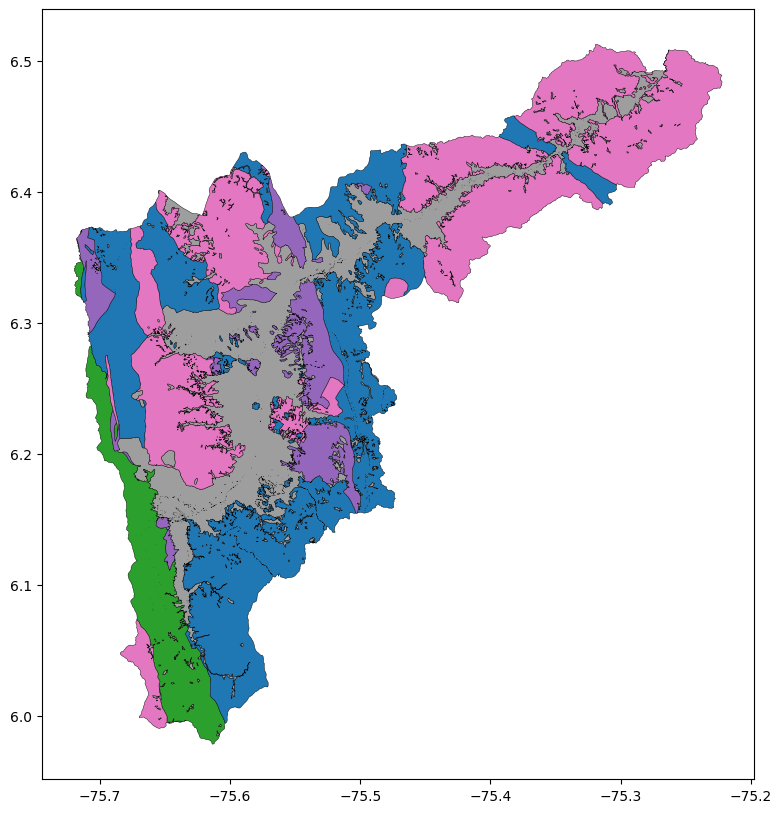

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

# --- Rutas ---
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/Geohazard_RS.gpkg"

path_dagrd = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/dagrd_12062025.csv"

# --- 1) Cargar geología ---
geo = gpd.read_file(geo_path, encoding="utf-8")
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
geo["Geologia"] = geo["Geologia"].astype("category")

# (Opcional pero recomendado para escala/norte correctos)
# geo = geo.to_crs(32618)  # UTM 18N Valle de Aburrá

# --- 2) Cargar inventario de deslizamientos ---
#abrir csv como geodataframe
inv_dagrd = pd.read_csv(path_dagrd)
inv_dagrd = gpd.GeoDataFrame(inv_dagrd, geometry=gpd.points_from_xy(inv_dagrd.longitud.values, inv_dagrd.latitud.values), crs="EPSG:4326")
inv = gpd.read_file(path_dagrd)

# Si el inventario no tiene CRS, asumimos el mismo que la geología (ajústalo si sabes el EPSG exacto del inventario)
if inv.crs is None and geo.crs is not None:
    inv.set_crs(geo.crs, inplace=True)

# Reproyectar al CRS de geología si difieren
if geo.crs is not None and inv.crs is not None and inv.crs != geo.crs:
    inv = inv.to_crs(geo.crs)

# --- 2.b) QUEDARSE SOLO CON LOS PUNTOS DENTRO DE GEOLOGÍA ---
inv_before = len(inv)

# Asegura geometrías válidas (evita topologías raras)
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)  # o usa shapely.make_valid si tienes Shapely 2.x

# Recortar (clip) los puntos del inventario al polígono de geología
inv = gpd.clip(inv, geo_valid)

print(f"Puntos antes: {inv_before} | Puntos dentro de geología: {len(inv)}")
# Si por alguna razón el inventario viene en polígonos/líneas y quieres puntos:
# inv = inv.copy()
# inv["geometry"] = inv.geometry.centroid

# --- 3) Graficar ---
import unicodedata
from matplotlib.lines import Line2D

# --- Normalizador (sin tildes, minúsculas) ---
def _norm(s):
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# --- Mapa de colores por categoría (claves normalizadas) ---
color_map_norm = {
    "depositos cuaternarios":        "#9e9e9e",  # gris
    "rocas metamorficas":            "#1f77b4",  # azul
    "rocas ultramaficas":            "#9467bd",  # morado
    "rocas volcanosedimentarias":    "#2ca02c",  # verde
    "rocas igneas intrusivas":       "#e377c2",  # rosado
}


# Mejor: que 'Geologia' NO sea categoría durante el mapeo
geo["Geologia"] = geo["Geologia"].astype(str)

geo["Geologia_norm"] = geo["Geologia"].apply(_norm)
s = geo["Geologia_norm"].map(color_map_norm)

geo["fillcolor"] = s.astype("object").fillna("#cccccc")
# --- Graficar con colores fijos ---
fig, ax = plt.subplots(figsize=(10, 10))

# Geología
geo.plot(ax=ax, facecolor=geo["fillcolor"], edgecolor="black", linewidth=0.3)

# Inventario (como ya lo tienes)
inv.plot(ax=ax, marker="o", color="black",
         edgecolor="black", linewidth=0.5,
         markersize=18, alpha=0.55, zorder=5)

#ax.set_title("Mapa de Unidades Geológicas + Inventario de Deslizamientos", fontsize=14)
ax.set_xlabel("Longitud" if geo.crs is None or (geo.crs and geo.crs.is_geographic) else "X (m)")
ax.set_ylabel("Latitud" if geo.crs is None or (geo.crs and geo.crs.is_geographic) else "Y (m)")
ax.set_aspect("equal")

# --- Leyenda manual en orden deseado + deslizamientos ---
orden_legenda = [
    ("Depósitos Cuaternarios",      "#9e9e9e"),
    ("Rocas Metamórficas",          "#1f77b4"),
    ("Rocas Ultramáficas",          "#9467bd"),
    ("Rocas Volcanosedimentarias",  "#2ca02c"),
    ("Rocas Ígneas Intrusivas",     "#e377c2"),
]

handles_geo = [Line2D([0], [0], marker='s', linestyle='',
                      markerfacecolor=c, markeredgecolor='black',
                      markersize=10, label=lab) for lab, c in orden_legenda]

handle_inv = Line2D([0], [0], marker='o', linestyle='', markerfacecolor='black',
                    markeredgecolor='black', markersize=8, label='Deslizamientos (inventario)')

labels_geo = [lab for lab, _ in orden_legenda]
labels = labels_geo + ["Deslizamientos (inventario)"]

ax.legend(handles=handles_geo + [handle_inv],
          labels=labels,
          title="Geología / Inventario",
          loc="lower right", frameon=True, fontsize=16, title_fontsize=18)


plt.tight_layout()
plt.show()

In [6]:
inv_dagrd.latitud

0       6.278856
1       6.267187
2       6.202118
3       6.251144
4       6.277537
          ...   
1746    6.250637
1747    6.239209
1748    6.294297
1749    6.256627
1750    6.202045
Name: latitud, Length: 1751, dtype: float64

### **GRAFICO DE BARRAS DE DESLIZAMIENTOS POR TIPO DE ROCA**

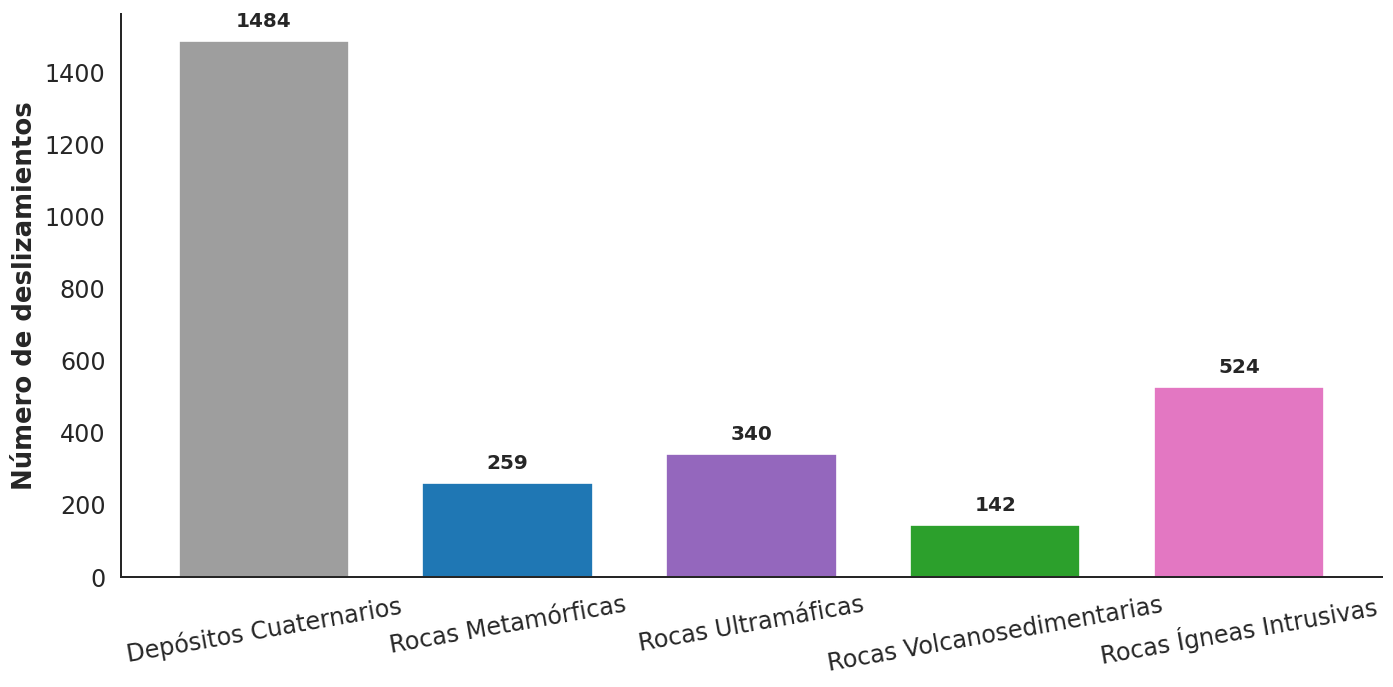

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# --- Normalizador (quita tildes y pasa a minúsculas) ---
def _norm(s):
    if s is None:
        return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# --- Colores fijos por unidad (claves normalizadas) ---
color_map_norm = {
    "depositos cuaternarios":        "#9e9e9e",  # gris
    "rocas metamorficas":            "#1f77b4",  # azul
    "rocas ultramaficas":            "#9467bd",  # morado
    "rocas volcanosedimentarias":    "#2ca02c",  # verde
    "rocas igneas intrusivas":       "#e377c2",  # rosado
}

# --- Etiquetas “bonitas” y orden deseado en la gráfica ---
orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]
# Mapa etiqueta bonita -> color
label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",
    "Rocas Metamórficas":         "#1f77b4",
    "Rocas Ultramáficas":         "#9467bd",
    "Rocas Volcanosedimentarias": "#2ca02c",
    "Rocas Ígneas Intrusivas":    "#e377c2",
}

# --- Rutas ------------------------
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/Geohazard_RS.gpkg"
# ---------- Cargar datos ----------
geo = gpd.read_file(geo_path, encoding="utf-8")
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
geo["Geologia"] = geo["Geologia"].astype("category")   
inv = gpd.read_file(inv_path)

# ---------- Asegurar CRS (si hiciera falta) ----------
geo = geo.to_crs(32618)                   # recomendado para V. de Aburrá (m)
inv = inv.to_crs(geo.crs)                 # igualar CRS

# ---------- Clip/sjoin: quedarnos con puntos dentro de geología ----------
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)  # “make valid” simple

# Une puntos con polígonos contenedores
inv_in = gpd.sjoin(inv, geo_valid[["Geologia","geometry"]], how="inner", predicate="within")

# ---------- Agregar conteos por unidad ----------
# Normalizamos para empatar con el dict de colores
inv_in["Geologia_norm"] = inv_in["Geologia"].apply(_norm)

# Creamos etiqueta bonita a partir de la normalizada
norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}
inv_in["Geologia_label"] = inv_in["Geologia_norm"].map(norm_to_label)

# Conteos (incluimos todas las clases del orden, aunque tengan 0)
counts = inv_in.groupby("Geologia_label").size().reindex(orden_labels, fill_value=0)
df_counts = counts.reset_index()
df_counts.columns = ["Unidad", "Conteo"]
df_counts["Color"] = df_counts["Unidad"].map(label_to_color)

# ---------- Graficar (formato similar a tu ejemplo) ----------
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(
    df_counts["Unidad"],
    df_counts["Conteo"],
    color=df_counts["Color"],
    width=0.7
)

# Etiquetas encima de cada barra (conteo entero)
for bar, n in zip(bars, df_counts["Conteo"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(df_counts["Conteo"])*0.02 if df_counts["Conteo"].max() > 0 else 0.2,
        f'{int(n)}',
        ha='center', va='bottom', fontsize=12, weight='bold'
    )

# Ejes y estilo
ax.set_ylabel('Número de deslizamientos', weight='bold')
ax.set_xlabel('')
ax.spines[['right', 'top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white')
ax.grid(False)
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

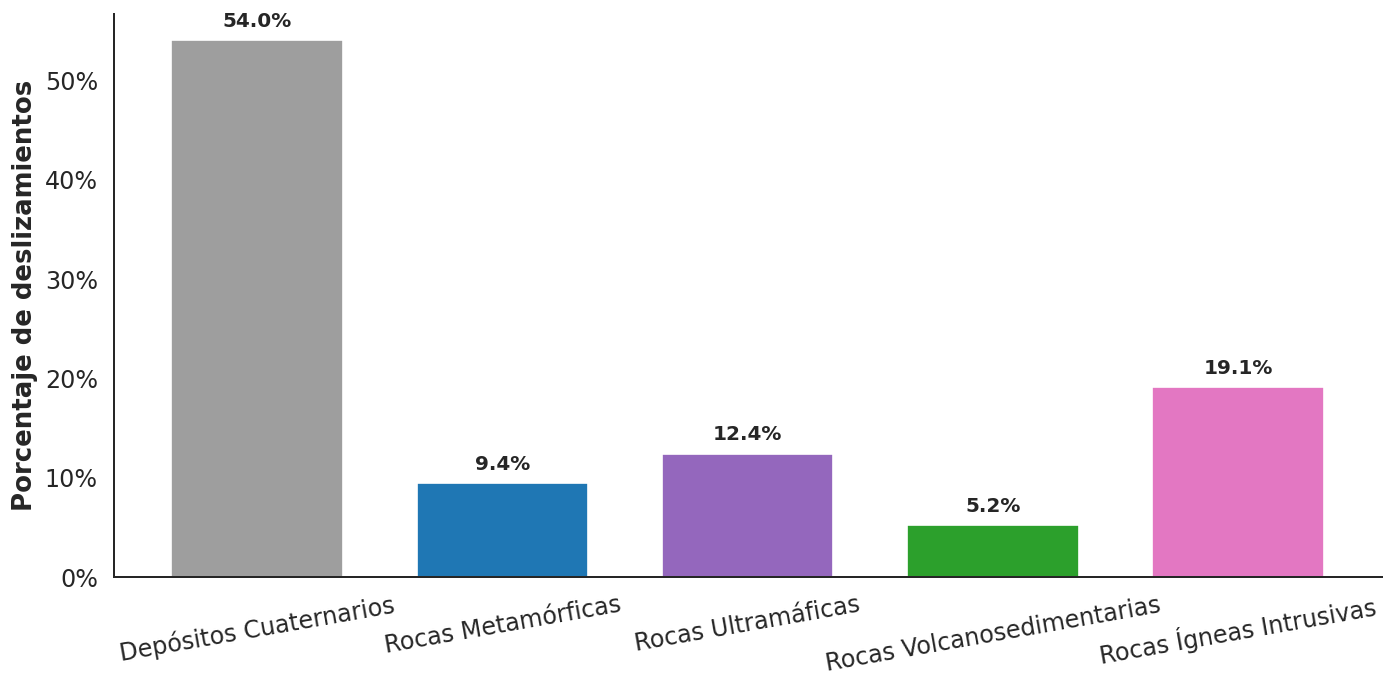

In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import unicodedata
from matplotlib.ticker import PercentFormatter

# --- Utilidades (usa las que ya tengas) ---
def _norm(s):
    if s is None: return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}

orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]

label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",  # gris
    "Rocas Metamórficas":         "#1f77b4",  # azul
    "Rocas Ultramáficas":         "#9467bd",  # morado
    "Rocas Volcanosedimentarias": "#2ca02c",  # verde
    "Rocas Ígneas Intrusivas":    "#e377c2",  # rosado
}

# --- 1) Asegurar CRS compatible para el join espacial (no hace falta metros para porcentajes) ---
if (geo.crs is not None) and (inv.crs != geo.crs):
    inv = inv.to_crs(geo.crs)

# --- 2) Puntos dentro del área de estudio (geología) ---
geo_valid = geo.copy()
geo_valid["geometry"] = geo_valid.buffer(0)

inv_in = gpd.sjoin(inv, geo_valid[["Geologia","geometry"]], how="inner", predicate="within")

# --- 3) Conteo por unidad y porcentaje sobre el total (dentro del área de estudio) ---
inv_in["Geologia_norm"]  = inv_in["Geologia"].apply(_norm)
inv_in["Geologia_label"] = inv_in["Geologia_norm"].map(norm_to_label)

counts = inv_in.groupby("Geologia_label").size().reindex(orden_labels, fill_value=0)
total  = counts.sum()

# Evitar división por cero si no hay puntos dentro
pct = (counts / total) if total > 0 else counts.astype(float)

df_pct = pd.DataFrame({
    "Unidad": orden_labels,
    "Porcentaje": pct.values,
    "Color": [label_to_color[u] for u in orden_labels]
})

# --- 4) Gráfico de barras (mismo estilo que tu ejemplo) ---
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(
    df_pct["Unidad"],
    df_pct["Porcentaje"],
    color=df_pct["Color"],
    width=0.7
)

# Etiquetas encima de cada barra (en %)
for bar, p in zip(bars, df_pct["Porcentaje"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        (bar.get_height() if total>0 else 0) + 0.01,
        f'{(p*100 if total>0 else 0):.1f}%',
        ha='center', va='bottom', fontsize=12, weight='bold'
    )

# Eje Y como porcentaje
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

# Etiquetas y estilo
ax.set_ylabel('Porcentaje de deslizamientos', weight='bold')
ax.set_xlabel('')
ax.spines[['right','top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white')
ax.grid(False)
ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

# (Opcional) Verificación rápida en consola
# print(pd.DataFrame({"Conteo": counts, "Porcentaje (%)": (pct*100 if total>0 else 0)}))


### **GRAFICO DE BARRAS DENSIDAD DE DESLIZAMIENTOS POR TIPO DE ROCA (N/km²)**

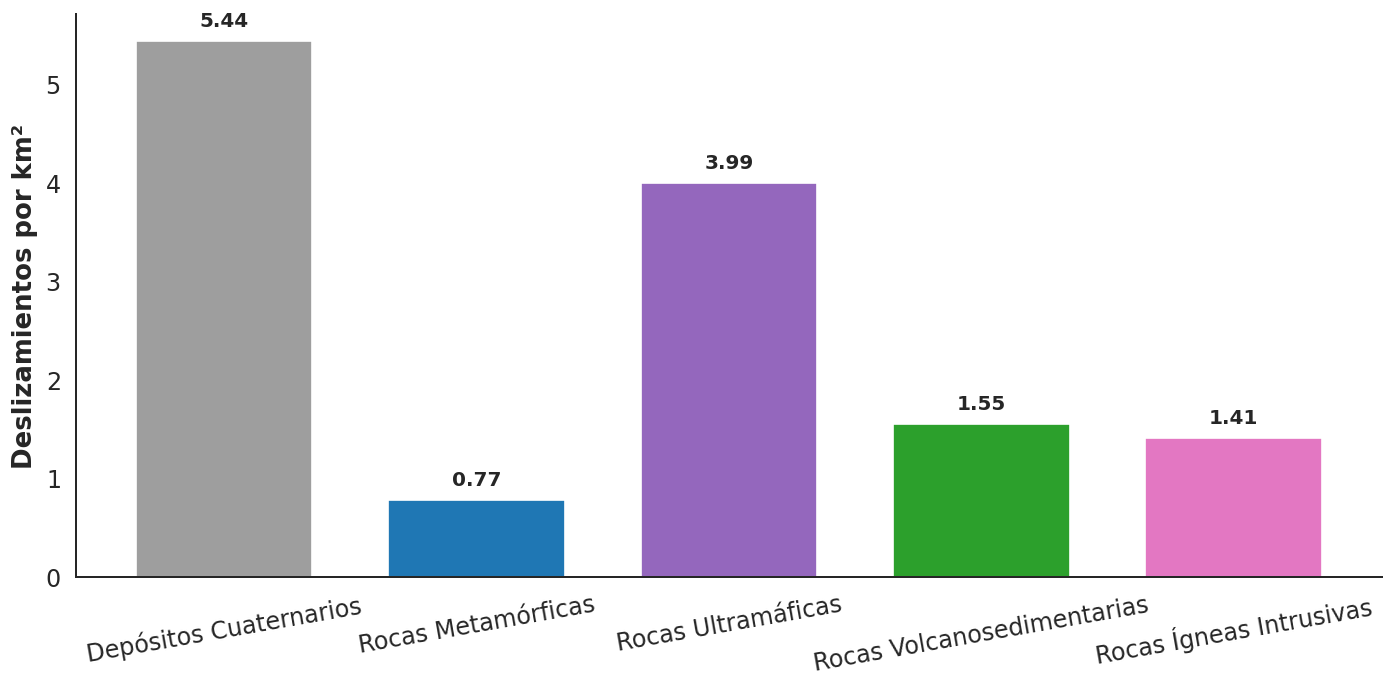

In [5]:
from shapely.ops import unary_union
from matplotlib.ticker import ScalarFormatter

# --- 0) parámetros y utilidades ---
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, unicodedata
from matplotlib.ticker import ScalarFormatter
import geopandas as gpd

def _norm(s):
    if s is None: return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}

orden_labels = [
    "Depósitos Cuaternarios",
    "Rocas Metamórficas",
    "Rocas Ultramáficas",
    "Rocas Volcanosedimentarias",
    "Rocas Ígneas Intrusivas",
]

label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",
    "Rocas Metamórficas":         "#1f77b4",
    "Rocas Ultramáficas":         "#9467bd",
    "Rocas Volcanosedimentarias": "#2ca02c",
    "Rocas Ígneas Intrusivas":    "#e377c2",
}

# --- Rutas ------------------------
geo_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
inv_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/Geohazard_RS.gpkg"

# ---------- Cargar datos ----------
geo = gpd.read_file(geo_path, encoding="utf-8")
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
# ¡No convertir a 'category' para evitar problemas al agregar!
# geo["Geologia"] = geo["Geologia"].astype("category")
inv = gpd.read_file(inv_path)

# --- 1) Asegurar CRS en metros (clave para el área) ---
if geo.crs is None or geo.crs.is_geographic:
    geo = geo.to_crs(32618)   # Cambia a 3116 si trabajas en MAGNA-SIRGAS oficial
if inv.crs != geo.crs:
    inv = inv.to_crs(geo.crs)

# --- 2) Normalizar y crear etiqueta "bonita" en GEOMETRÍAS y PUNTOS ---
geo_valid = geo.copy()
# Arreglar geometrías simples
geo_valid["geometry"] = geo_valid.buffer(0)

geo_valid["Geologia_norm"]  = geo_valid["Geologia"].apply(_norm)
geo_valid["Geologia_label"] = geo_valid["Geologia_norm"].map(norm_to_label)
# Nos quedamos solo con las clases de interés (para que área y conteo coincidan)
geo_valid = geo_valid.loc[geo_valid["Geologia_label"].isin(orden_labels), ["Geologia_label", "geometry"]].copy()

# --- 3) Área por unidad (disolver por etiqueta bonita y medir km²) ---
# Disolver usando SOLO etiqueta y geometría (no sumar columnas problemáticas)
geo_diss = geo_valid.dissolve(by="Geologia_label", as_index=True)
geo_diss["area_km2"] = geo_diss.geometry.area / 1e6  # m² → km²
df_area = geo_diss[["area_km2"]].reindex(orden_labels)

# --- 4) Conteo de deslizamientos por unidad (usando MISMAS etiquetas) ---
# Asignar a cada punto la unidad geológica mediante sjoin
inv_in = gpd.sjoin(inv, geo_valid, how="inner", predicate="within")

# Conteos y colores
df_counts = (
    inv_in.groupby("Geologia_label")
    .size()
    .reindex(orden_labels, fill_value=0)
    .reset_index()
    .rename(columns={"Geologia_label": "Unidad", 0: "Conteo"})
)
df_counts["Color"] = df_counts["Unidad"].map(label_to_color)

# --- 5) Densidad = Conteo / Área_km² ---
df_den = df_counts.set_index("Unidad").join(df_area, how="left")
df_den["area_km2"] = df_den["area_km2"].replace(0, np.nan)  # evitar división por 0
df_den["Densidad"]  = df_den["Conteo"] / df_den["area_km2"]

# --- 6) Graficar ---
sns.set_theme(style='white', font='DejaVu Sans', font_scale=1.3)
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)

bars = ax.bar(df_den.index, df_den["Densidad"], color=df_den["Color"], width=0.7)

# Etiquetas encima
y_offset = (df_den["Densidad"].max() or 0) * 0.02
y_offset = y_offset if y_offset > 0 else 0.05
for bar, d in zip(bars, df_den["Densidad"]):
    if pd.notna(d):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + y_offset,
                f'{d:.2f}', ha='center', va='bottom', fontsize=12, weight='bold')

ax.set_ylabel('Deslizamientos por km²', weight='bold'); ax.set_xlabel('')
ax.spines[['right', 'top']].set_visible(False)
ax.spines['left'].set_linewidth(1.2); ax.spines['bottom'].set_linewidth(1.2)
ax.set_facecolor('white'); ax.grid(False); ax.tick_params(axis='x', rotation=10)
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='plain', useMathText=True)

plt.tight_layout(); plt.show()

# (Opcional) inspección rápida:
# print(df_den[["Conteo","area_km2","Densidad"]])

### **GRAFICO DE DISPERSIÓN**

In [6]:
# =========================
# 1) Imports y utilidades
# =========================
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
from shapely.geometry import Point
from matplotlib import pyplot as plt
from matplotlib.ticker import ScalarFormatter
import unicodedata

# -------- Normalizador geológico --------
def _norm(s):
    if s is None: return ""
    s = str(s).strip()
    s = unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    return s.lower()

# -------- Mapeos de geología (color) y zonas (marcador/etiqueta) --------
label_to_color = {
    "Depósitos Cuaternarios":     "#9e9e9e",
    "Rocas Metamórficas":         "#1f77b4",
    "Rocas Ultramáficas":         "#9467bd",
    "Rocas Volcanosedimentarias": "#2ca02c",
    "Rocas Ígneas Intrusivas":    "#e377c2",
}
norm_to_label = {
    "depositos cuaternarios": "Depósitos Cuaternarios",
    "rocas metamorficas": "Rocas Metamórficas",
    "rocas ultramaficas": "Rocas Ultramáficas",
    "rocas volcanosedimentarias": "Rocas Volcanosedimentarias",
    "rocas igneas intrusivas": "Rocas Ígneas Intrusivas",
}
orden_labels = list(label_to_color.keys())

marker_por_zona = {1: 's', 2: '^', 3: 'o', 4: 'D', 5: 'P'}
zona_label      = {1: 'Oriente', 2: 'Norte', 3: 'Sur', 4: 'Sap', 5: 'Occidente'}

# -------- Tamaños por densidad (cuartiles por defecto) --------
def _build_size_by_density(df, metric='dens_mm_km2', use_quantiles=True):
    size_levels = [60, 140, 260, 420]
    x = df[metric].replace([np.inf, -np.inf], np.nan).fillna(0)

    if use_quantiles and x.notna().any():
        q1, q2, q3 = x.quantile([0.25, 0.50, 0.75]).values
        bins = [-np.inf, q1, q2, q3, np.inf]
        bin_labels = ['≤ Q1', 'Q1–Q2', 'Q2–Q3', '> Q3']
        display_labels = [
            f"≤ Q1 (≤ {q1:.2f})",
            f"Q1–Q2 ({q1:.2f}–{q2:.2f})",
            f"Q2–Q3 ({q2:.2f}–{q3:.2f})",
            f"> Q3 (> {q3:.2f})"
        ]
    else:
        bins = [-np.inf, 0.02, 0.05, 0.10, np.inf]
        bin_labels = ['≤ 0.02', '0.02–0.05', '0.05–0.10', '> 0.10']
        display_labels = bin_labels[:]

    cats = pd.cut(x, bins=bins, labels=bin_labels, right=True)
    size_map = dict(zip(bin_labels, size_levels))
    sizes = cats.map(size_map).fillna(size_levels[0]).astype(float).values

    return sizes, bin_labels, size_map, display_labels

# =========================
# 2) Entradas
# =========================
zona_lluvia_path = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/clusters.shp"
geo_path         = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/shape_files/geo.shp"
eventos_path     = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/eventos_lluvia_5mm_1horas_2.nc"
acumulados_paths = {
    "1_dia":  "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_1d.nc",
    "15_dias":"/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_15d.nc",
    "30_dias":"/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_30d.nc",
    "60_dias":"/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_60d.nc",
    "90_dias":"/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/rainfall/radar/estadisticos_acum_90d.nc"
}
inv_path         = "/home/oisanchezp/PAPER_RainfallLandslides_Vdea/DATA/landslides/Geohazard_RS.gpkg"

# Nombre de columna de la capa de zonas (¡ajusta aquí si tu shapefile usa otro!)
ZONA_COL = "NOMBRE"       # p.ej. "zona" o "cluster" o "id"
PROJ = 32618            # Usa 3116 si trabajas en MAGNA-SIRGAS oficial


# =========================
# 3) Preparación espacial
# =========================
# Leer zonas y geología
zones = gpd.read_file(zona_lluvia_path)
geo   = gpd.read_file(geo_path, encoding="utf-8")
inv   = gpd.read_file(inv_path)

# Asegurar CRS: proyectar a metros para áreas y distancias
if zones.crs is None or zones.crs.is_geographic:
    zones = zones.to_crs(PROJ)
else:
    zones = zones.to_crs(PROJ)

if geo.crs is None or geo.crs.is_geographic:
    geo = geo.to_crs(PROJ)
else:
    geo = geo.to_crs(PROJ)

if inv.crs != zones.crs:
    inv = inv.to_crs(zones.crs)

# Arreglar geometrías simples
zones["geometry"] = zones.buffer(0)
geo["geometry"]   = geo.buffer(0)

# Normalizar geología y etiquetar “bonito”
assert "Geologia" in geo.columns, "No encuentro la columna 'Geologia' en el shapefile de geología."
geo["Geologia_norm"]  = geo["Geologia"].apply(_norm)
geo["Geologia_label"] = geo["Geologia_norm"].map(norm_to_label)

# Filtrar a clases con color definido
geo = geo.loc[geo["Geologia_label"].isin(orden_labels), ["Geologia_label", "geometry"]].copy()

# Validar columna de zona
assert ZONA_COL in zones.columns, f"No encuentro la columna '{ZONA_COL}' en el shapefile de zonas."

# Intersección zona × geología → unidades de análisis
inter = gpd.overlay(geo, zones[[ZONA_COL, "geometry"]], how="intersection")
inter["area_km2"] = inter.geometry.area / 1e6

# =========================
# 4) Convertir grillas .nc a puntos
# =========================
def nc_to_points_df(nc_path, var_rename=None):
    """
    Carga un .nc con dims (lon, lat) y devuelve GeoDataFrame de puntos (centroides de celdas)
    con columnas de variables. var_rename permite renombrar columnas.
    """
    ds = xr.open_dataset(nc_path)
    # Asegurar nombres
    assert "lon" in ds.coords and "lat" in ds.coords, "El .nc debe tener coords 'lon' y 'lat'."
    # Seleccionar variables numéricas
    vars_numeric = [v for v in ds.data_vars if np.issubdtype(ds[v].dtype, np.number)]
    da = ds[vars_numeric].to_array().transpose("lon", "lat", "variable")  # (lon, lat, var)
    # Convertir a DataFrame
    df = ds[vars_numeric].to_dataframe().reset_index()  # columnas: lon, lat, var...
    # Construir geometría en WGS84 y proyectar
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=4326)
    gdf = gdf.to_crs(PROJ)
    # Renombrar si aplica
    if var_rename:
        gdf = gdf.rename(columns=var_rename)
    return gdf

# Cargar eventos (usa nombres exactos en tu .nc)
# Ajusta var_rename si tus variables tienen otros nombres
eventos_gdf = nc_to_points_df(
    eventos_path,
    # var_rename={
    #     # si tus nombres ya coinciden, puedes omitir este dict
    #     # 'num_eventos': 'num_eventos',
    #     # 'intensidad_promedio': 'intensidad_promedio',
    #     # 'intensidad_maxima_promedio': 'intensidad_maxima_promedio',
    #     # 'duracion_promedio': 'duracion_promedio',
    #     # 'acumulado_promedio': 'acumulado_promedio',
    # }
)

# Cargar acumulados (tomamos la variable 'mean' de cada archivo y la renombramos)
acum_list = []
for key, path in acumulados_paths.items():
    ds = xr.open_dataset(path)
    assert "mean" in ds.data_vars, f"El archivo {path} no tiene variable 'mean'."
    df = ds[["mean"]].to_dataframe().reset_index()
    gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=4326).to_crs(PROJ)
    gdf = gdf.rename(columns={"mean": f"acum_{key}_mean"})
    acum_list.append(gdf[["geometry", f"acum_{key}_mean"]])

# Unir acumulados por geometría (mismo grid → mismo punto)
# Empezamos del eventos_gdf, hacemos joins espaciales exactos por índice (asumimos misma malla y orden)
# Para estar seguros, hacemos un "sjoin_nearest" con un umbral pequeño si hiciera falta.
base = eventos_gdf.copy()
for gdf_a in acum_list:
    # Usar sjoin_nearest por seguridad (si el grid es idéntico, matcheará 1 a 1)
    joined = gpd.sjoin_nearest(gdf_a, base[["geometry"]], how="left", distance_col="dist_join")
    col = [c for c in gdf_a.columns if c.startswith("acum_")][0]
    base[col] = joined[col].values

grid_points = base  # contiene eventos + acumulados por punto (en CRS PROJ)

# =========================
# 5) Agregación por intersección (zona×geología)
# =========================
# a) Asignar cada punto de grid a una intersección (zona×geo)
pts_in = gpd.sjoin(grid_points, inter[[ZONA_COL, "Geologia_label", "geometry"]], how="inner", predicate="within")

# b) Promedios por (zona, geología)
num_cols = [c for c in pts_in.columns if c not in ["index_right", ZONA_COL, "Geologia_label", "geometry"]]
agg_rain = pts_in.groupby([ZONA_COL, "Geologia_label"])[num_cols].mean().reset_index()

# c) Área por (zona, geología)
areas = inter.groupby([ZONA_COL, "Geologia_label"], as_index=False)["area_km2"].sum()

# d) Conteo de deslizamientos y densidad
inv_in = gpd.sjoin(inv, inter[[ZONA_COL, "Geologia_label", "geometry"]], how="inner", predicate="within")
land_counts = inv_in.groupby([ZONA_COL, "Geologia_label"]).size().reset_index(name="N_desliz")

# Merge maestro
df = (
    agg_rain
    .merge(areas, on=[ZONA_COL, "Geologia_label"], how="left")
    .merge(land_counts, on=[ZONA_COL, "Geologia_label"], how="left")
)

df["N_desliz"] = df["N_desliz"].fillna(0).astype(int)
df["dens_mm_km2"] = np.where(df["area_km2"] > 0, df["N_desliz"] / df["area_km2"], 0.0)
df["zona_name"]   = df[ZONA_COL].map(zona_label)
df["color"]       = df["Geologia_label"].map(label_to_color)

<frozen importlib._bootstrap>:219: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']
Únicos en df_final[NOMBRE]: ['Norte' 'Occidente' 'Oriente' 'Sap' 'Sur']


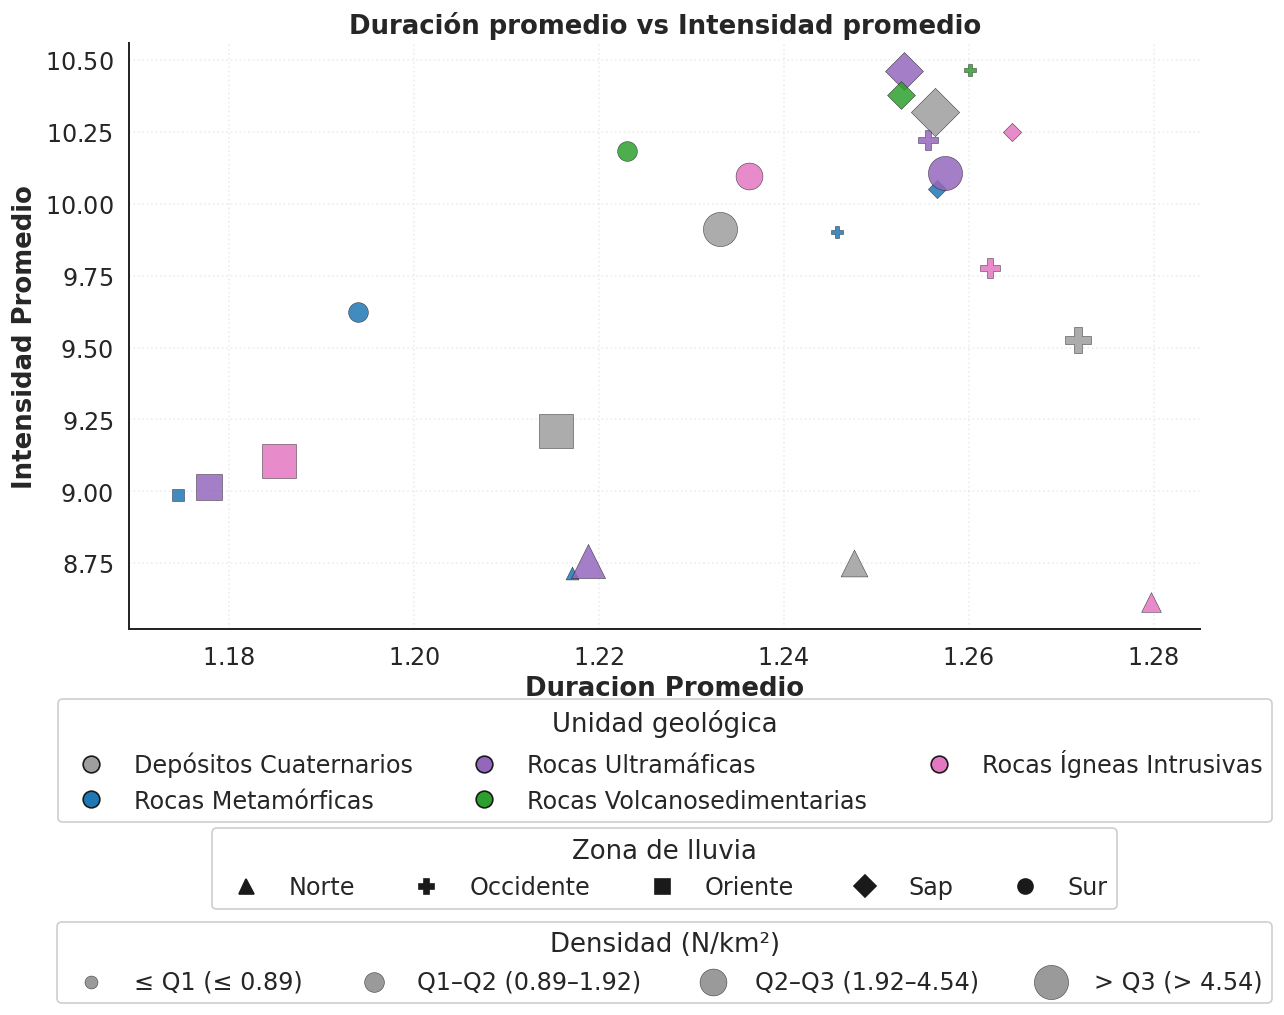

<Axes: title={'center': 'Duración promedio vs Intensidad promedio'}, xlabel='Duracion Promedio', ylabel='Intensidad Promedio'>

In [12]:
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D


# Diccionarios “oficiales”
marker_por_zona = {1: 's', 2: '^', 3: 'o', 4: 'D', 5: 'P'}
zona_label      = {1: 'Oriente', 2: 'Norte', 3: 'Sur', 4: 'SAP', 5: 'Occidente'}


def _build_markers_auto(df, zona_col):
    """
    Devuelve:
      - markers_map: dict valor_de_zona -> marcador
      - legend_handles: handles para la leyenda de zonas
    Si zona_col coincide con los IDs {1..5}, usa marker_por_zona.
    Si viene con nombres (p. ej. 'Norte'), mapea nombres -> IDs conocidos si coinciden,
    de lo contrario asigna marcadores cíclicamente.
    """
    valores = pd.unique(df[zona_col])
    valores = [v for v in valores if pd.notna(v)]

    # Caso 1: valores son enteros y están en el dict estándar
    if pd.api.types.is_integer_dtype(df[zona_col]) and set(valores).issubset(set(marker_por_zona.keys())):
        markers_map = {v: marker_por_zona[int(v)] for v in valores}
        legend_handles = [
            Line2D([], [], marker=marker_por_zona[i], color='k', linestyle='None',
                   label=zona_label.get(i, str(i)), markersize=9)
            for i in sorted(valores)
        ]
        return markers_map, legend_handles

    # Caso 2: vienen como nombres (intenta mapearlos a IDs oficiales)
    inv_zona_label = {v: k for k, v in zona_label.items()}  # 'Norte' -> 2, etc.
    markers_map = {}
    used_ids = set()
    free_ids = [k for k in marker_por_zona.keys()]

    for v in valores:
        if v in inv_zona_label:
            zid = inv_zona_label[v]
            markers_map[v] = marker_por_zona[zid]
            used_ids.add(zid)
        else:
            # asigna marcadores libres cíclicamente
            zid = free_ids[len(markers_map) % len(free_ids)]
            markers_map[v] = marker_por_zona[zid]

    # Leyenda con los nombres reales presentes
    legend_handles = [
        Line2D([], [], marker=markers_map[v], color='k', linestyle='None',
               label=str(v), markersize=9)
        for v in valores
    ]
    return markers_map, legend_handles


def scatter_lluvia(
    df,
    xvar,
    yvar,
    size_metric="dens_mm_km2",
    use_quantiles=True,
    title=None,
    figsize=(10, 8),
    alpha=0.85,
    edgecolor="k",
    lw=0.3,
    ZONA_COL="zona",
):
    """
    Grafica X vs Y:
      - Color = unidad geológica (label_to_color)
      - Marcador = zona (auto-detecta si es ID o nombre)
      - Tamaño = densidad (cuartiles o umbrales fijos)
    """
    # 0) Validaciones básicas
    if xvar not in df.columns or yvar not in df.columns:
        raise ValueError(f"xvar/yvar no existen en df. Recibí xvar='{xvar}', yvar='{yvar}'")

    df_plot = df.copy()

    # 1) Limpiar/asegurar numéricos en x/y
    df_plot[xvar] = pd.to_numeric(df_plot[xvar], errors="coerce")
    df_plot[yvar] = pd.to_numeric(df_plot[yvar], errors="coerce")
    df_plot = df_plot.dropna(subset=[xvar, yvar])

    if df_plot.empty:
        print("¡Advertencia! No hay datos válidos para graficar (NaNs en x/y o filtros previos).")
        fig, ax = plt.subplots(figsize=figsize, dpi=120)
        ax.set_title(title or f"{xvar} vs {yvar}")
        return ax

    # 2) Tamaños por densidad (como Series alineada por índice)
    sizes_arr, bin_labels, size_map, display_labels = _build_size_by_density(
        df_plot, metric=size_metric, use_quantiles=use_quantiles
    )
    sizes = pd.Series(sizes_arr, index=df_plot.index)

    # 3) Marcadores por zona (auto)
    markers_map, marker_handles = _build_markers_auto(df_plot, ZONA_COL)

    # 4) Figura (reservamos espacio inferior para leyendas con 'rect')
    fig, ax = plt.subplots(figsize=figsize, dpi=120)
    # deja 28% inferior (ajusta si necesitas más/menos)
    fig.tight_layout(rect=(0, 0.28, 1, 1))

    # 5) Pintar por zona y geología
    plotted = False
    for zona_val, mk in markers_map.items():
        sel_z = df_plot[df_plot[ZONA_COL] == zona_val]
        if sel_z.empty:
            continue
        for geo_lab, color in label_to_color.items():
            sel = sel_z[sel_z["Geologia_label"] == geo_lab]
            if sel.empty:
                continue
            ax.scatter(
                sel[xvar], sel[yvar],
                s=sizes.loc[sel.index].values,
                c=color,
                marker=mk,
                alpha=alpha,
                edgecolors=edgecolor,
                linewidths=lw,
            )
            plotted = True

    if not plotted:
        print("No se pintó ningún punto. Revisa valores de zona y Geologia_label.")
        print("Únicos en df[ZONA_COL]:", pd.unique(df[ZONA_COL]))
        print("Únicos en df['Geologia_label']:", pd.unique(df["Geologia_label"]))
        return ax

    # 6) Ejes y estilo
    ax.set_xlabel(xvar.replace("_", " ").title(), weight='bold')
    ax.set_ylabel(yvar.replace("_", " ").title(), weight='bold')
    if title:
        ax.set_title(title, weight='bold')

    ax.spines[['right', 'top']].set_visible(False)
    ax.spines['left'].set_linewidth(1.2); ax.spines['bottom'].set_linewidth(1.2)
    ax.set_facecolor('white'); ax.grid(True, ls=":", alpha=0.35)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='both', style='plain', useMathText=True)

    # 7) Leyendas en la parte inferior (3 bloques)
    # Colores (geología)
    color_handles = [
        Line2D([], [], marker='o', color='none', markerfacecolor=col, markeredgecolor='k',
               markersize=10, label=lab) for lab, col in label_to_color.items()
    ]
    # Marcadores (zonas) - ya construidos por _build_markers_auto
    # Tamaños (densidad)
    size_handles = [
        plt.scatter([], [], s=size_map[bl], c="#888888", alpha=0.85,
                    edgecolors="k", linewidths=0.3, label=display_labels[i])
        for i, bl in enumerate(bin_labels)
    ]

    # Colocación en banda inferior
    leg1 = ax.legend(handles=color_handles, title="Unidad geológica",
                     loc="upper center", bbox_to_anchor=(0.50, -0.10),
                     ncol=3, frameon=True, fancybox=True, framealpha=0.95)
    ax.add_artist(leg1)

    leg2 = ax.legend(handles=marker_handles, title="Zona de lluvia",
                     loc="upper center", bbox_to_anchor=(0.50, -0.32),
                     ncol=max(1, len(marker_handles)), frameon=True, fancybox=True, framealpha=0.95)
    ax.add_artist(leg2)

    leg3 = ax.legend(handles=size_handles, title="Densidad (N/km²)",
                     loc="upper center", bbox_to_anchor=(0.50, -0.48),
                     ncol=len(size_handles), frameon=True, fancybox=True, framealpha=0.95)

    plt.show()
    return ax

# =========================
# 7) DataFrame final y ejemplos de uso
# =========================
# DataFrame ordenado
cols_front = [ZONA_COL, "Geologia_label", "area_km2", "N_desliz", "dens_mm_km2"]
rain_cols = [c for c in df.columns if c.startswith(("intensidad","duracion","acumulado","num_eventos","acum_"))]
df_final = df[cols_front + rain_cols].sort_values([ZONA_COL, "Geologia_label"]).reset_index(drop=True)

print("Columnas disponibles para graficar X/Y:\n", rain_cols)

# Ejemplos de gráficos (descomenta el que necesites):
# 1) Duración vs Intensidad
# Verifica cómo viene tu columna de zona
print("Únicos en df_final[NOMBRE]:", df_final["NOMBRE"].unique())

# Ejemplo
scatter_lluvia(
    df_final,
    xvar="duracion_promedio",
    yvar="intensidad_promedio",
    title="Duración promedio vs Intensidad promedio",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)

# 2) Acumulado 1 día vs Intensidad
# scatter_lluvia(df_final, xvar="acum_1_dia_mean", yvar="intensidad_promedio",
#                title="Acumulado 1 día (mean) vs Intensidad promedio")

# 3) Acumulado 90 días vs Acumulado 1 día
# scatter_lluvia(df_final, xvar="acum_90_dias_mean", yvar="acum_1_dia_mean",
#                title="Acumulado 90 días (mean) vs Acumulado 1 día (mean)")

# df_final  # <- inspecciona la tabla final si quieres

Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


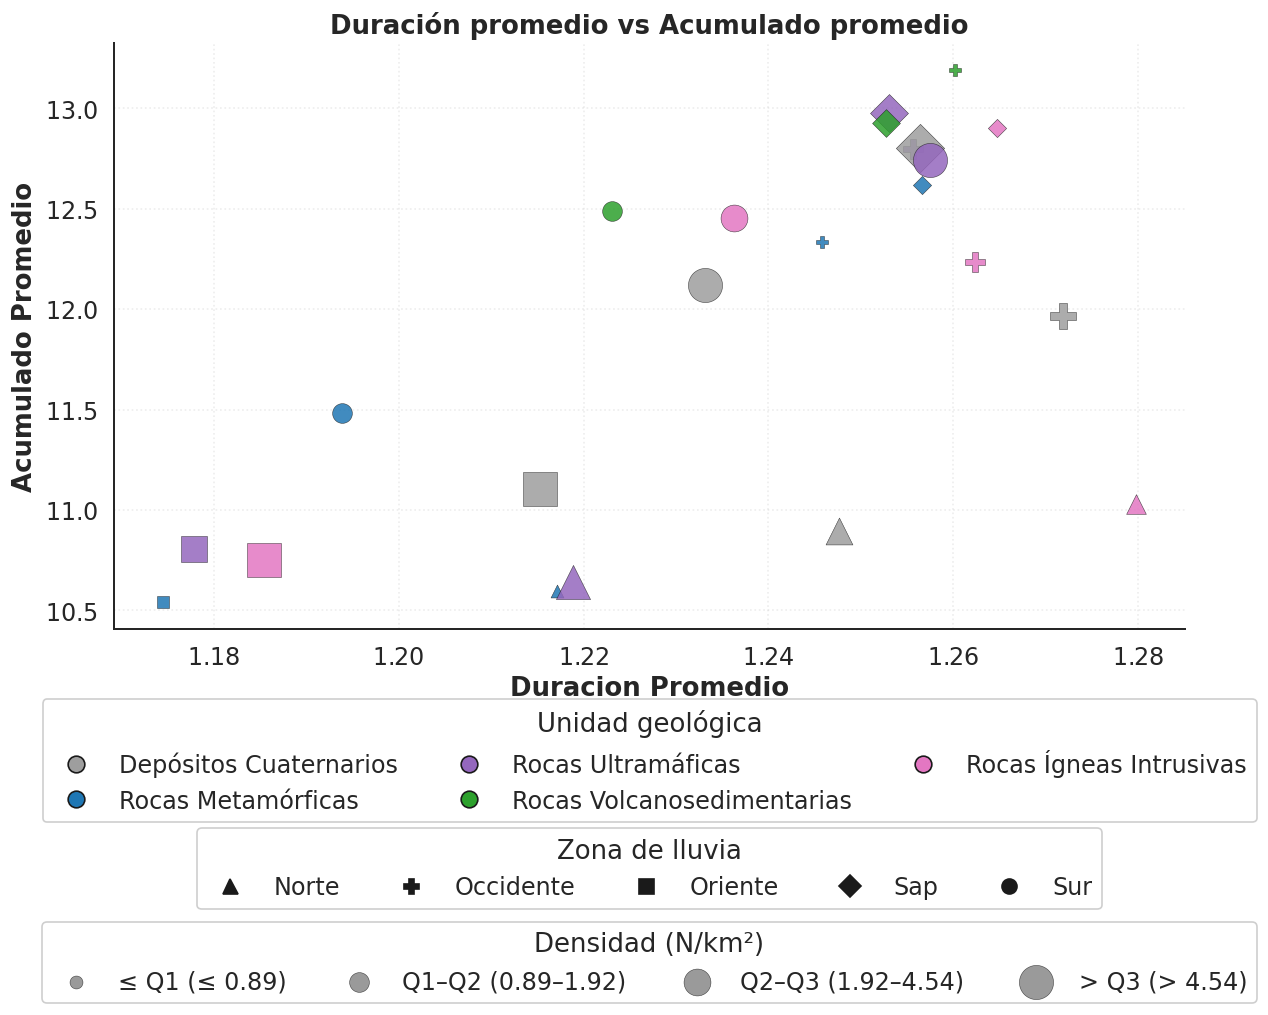

In [13]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="duracion_promedio",
    yvar="acumulado_promedio",
    title="Duración promedio vs Acumulado promedio",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)

Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


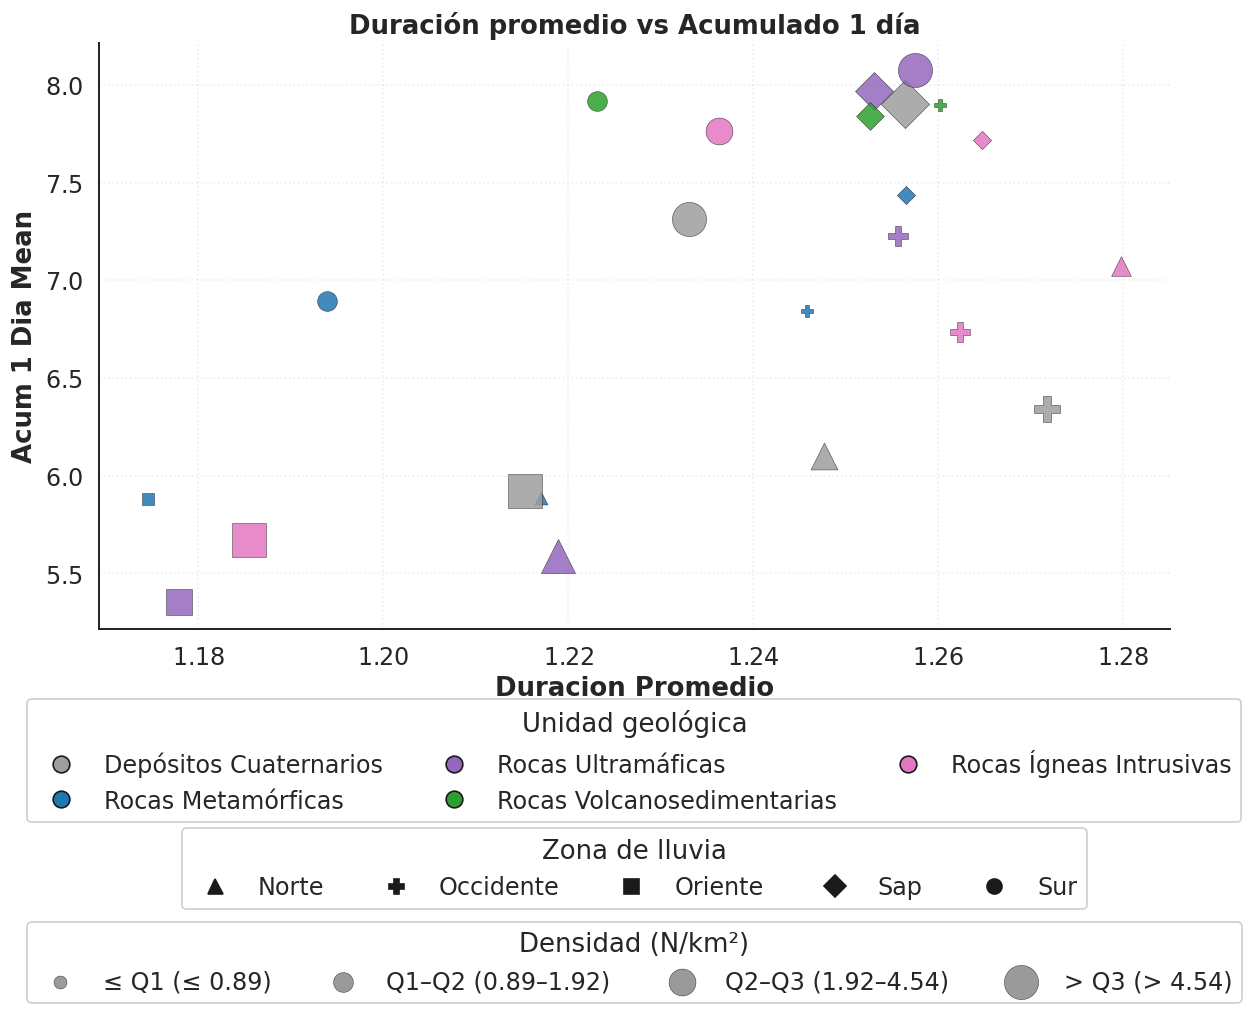

In [14]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="duracion_promedio",
    yvar="acum_1_dia_mean",
    title="Duración promedio vs Acumulado 1 día",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)

Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


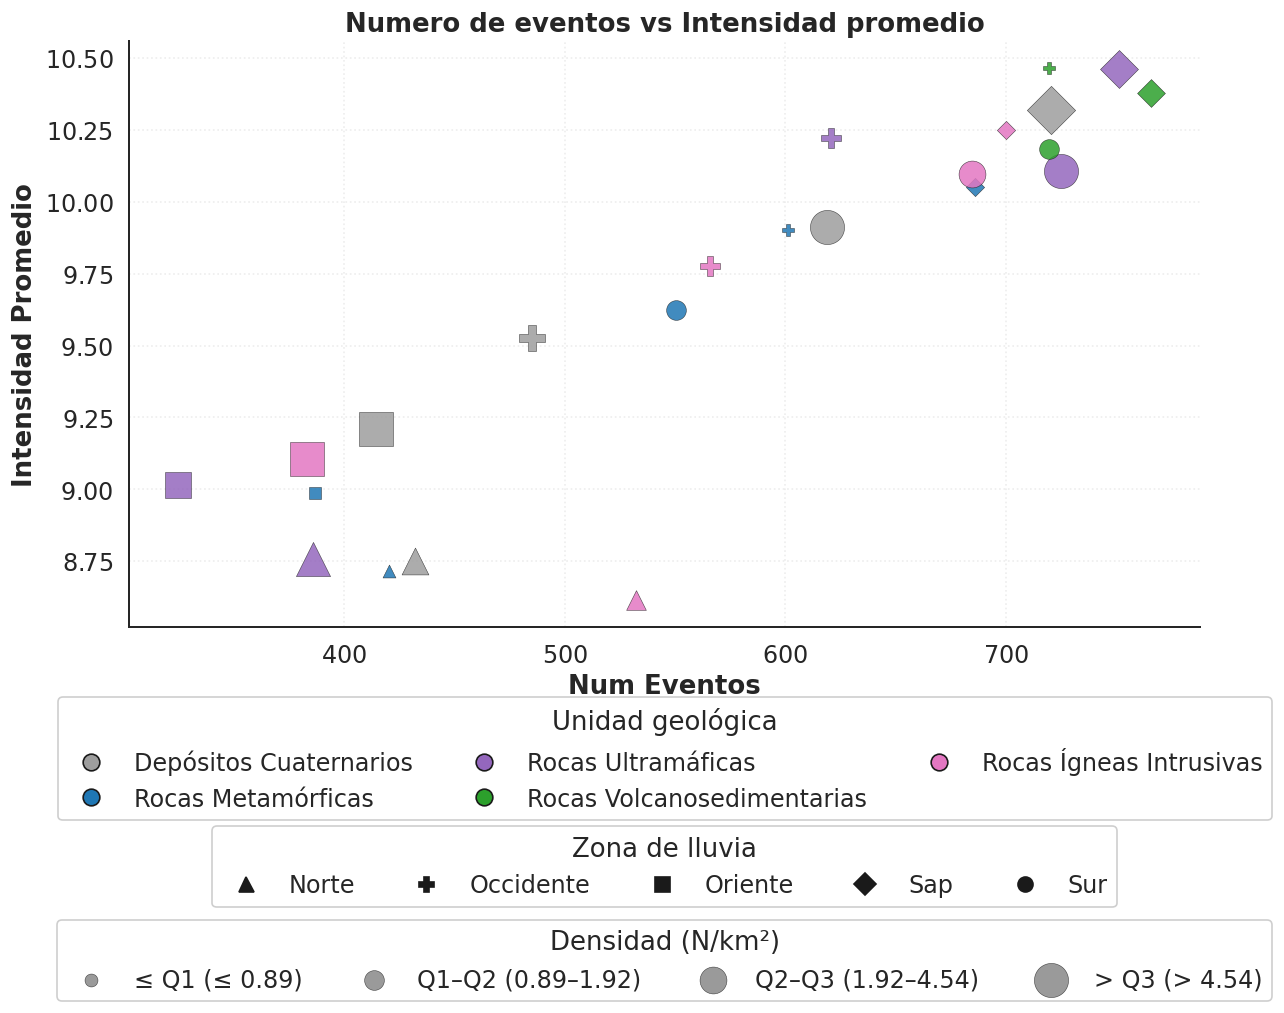

In [15]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="num_eventos",
    yvar="intensidad_promedio",
    title="Numero de eventos vs Intensidad promedio",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)


Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


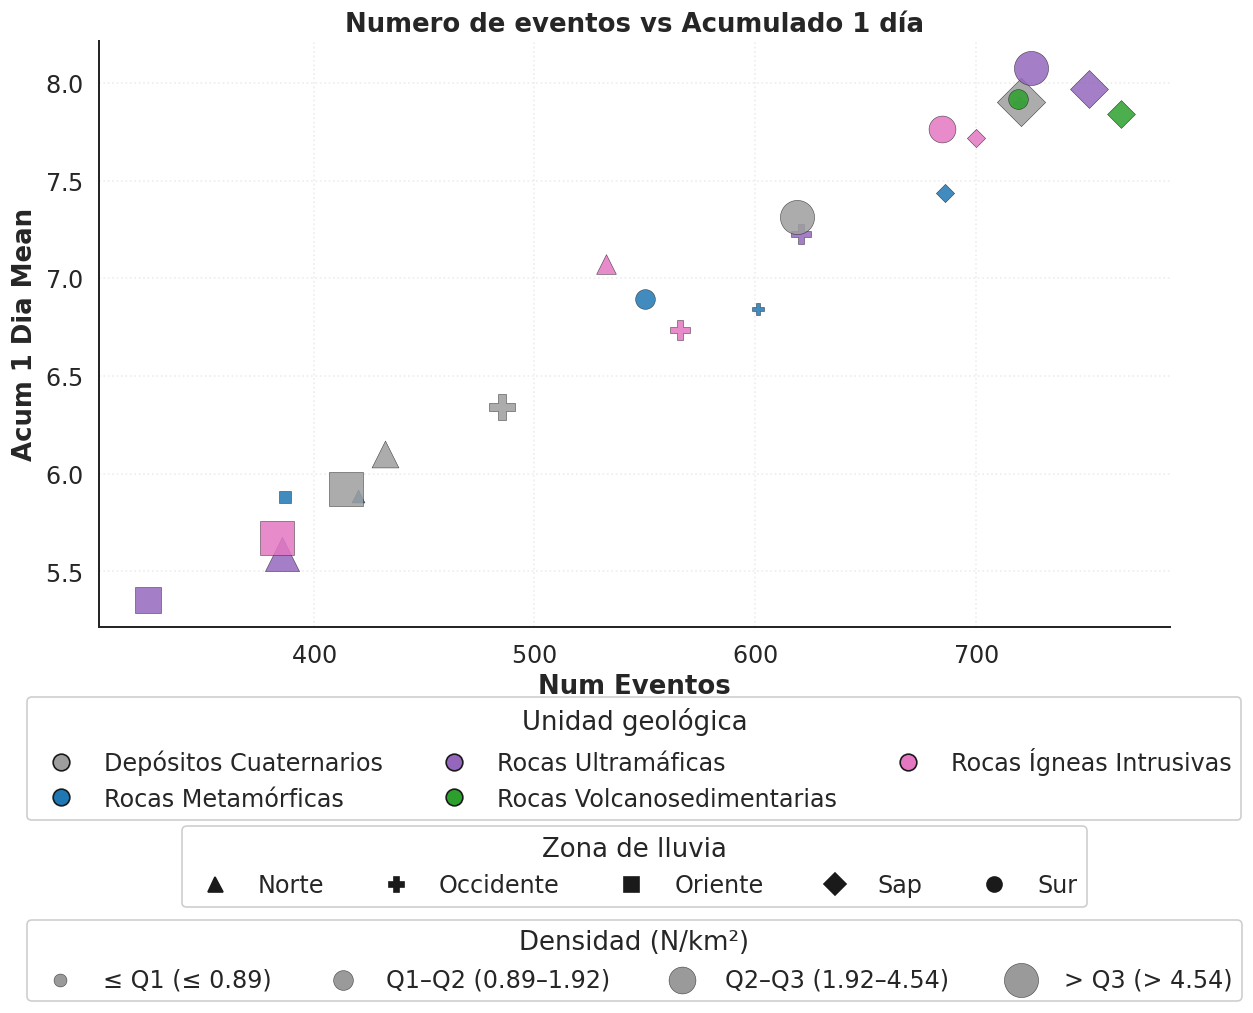

In [16]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="num_eventos",
    yvar="acum_1_dia_mean",
    title="Numero de eventos vs Acumulado 1 día",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)


Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


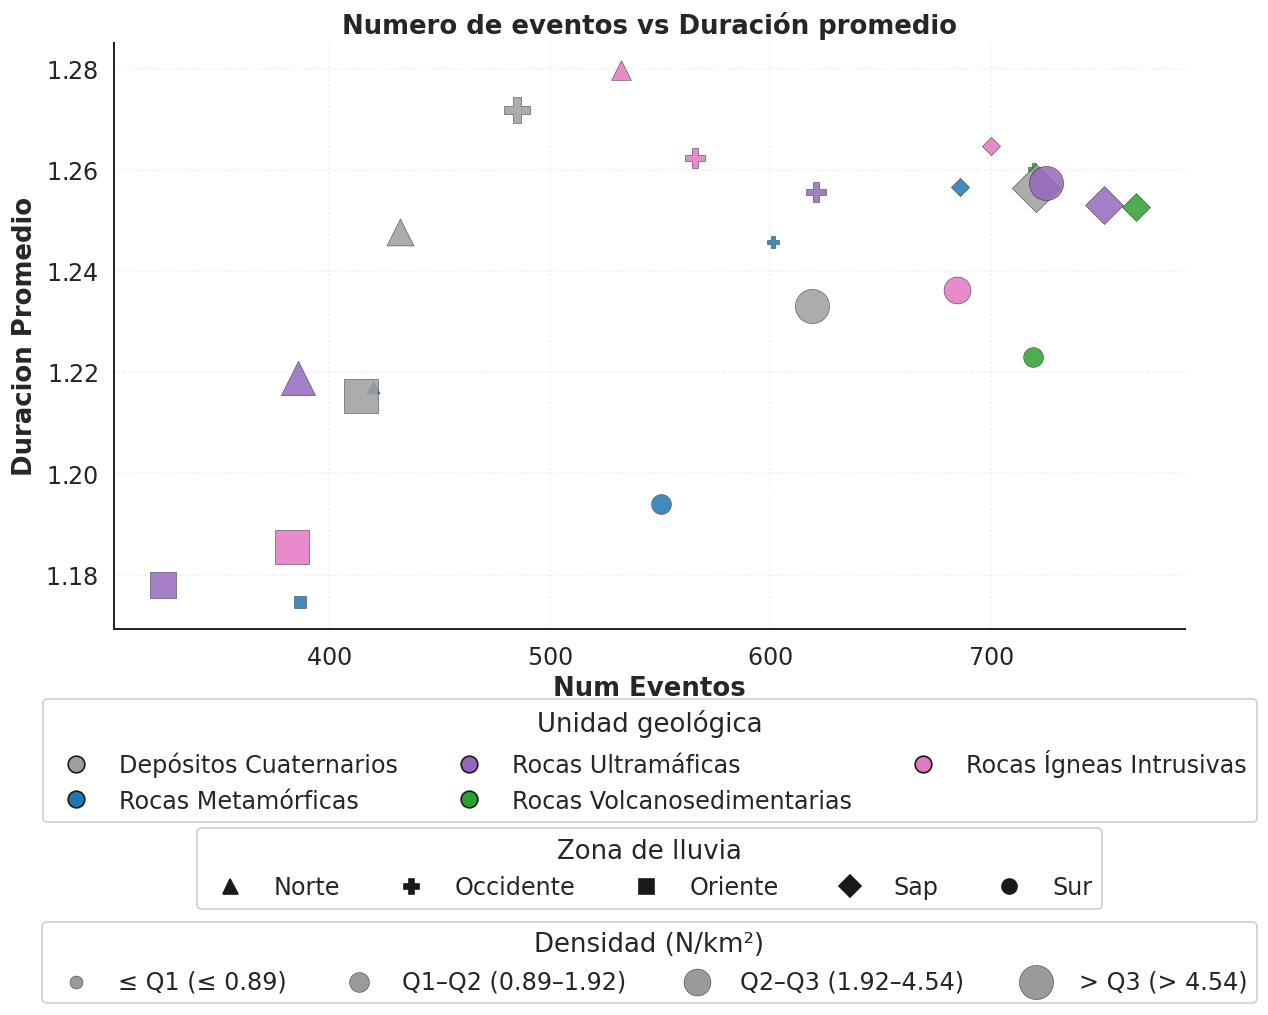

In [17]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="num_eventos",
    yvar="duracion_promedio",
    title="Numero de eventos vs Duración promedio",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)


Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


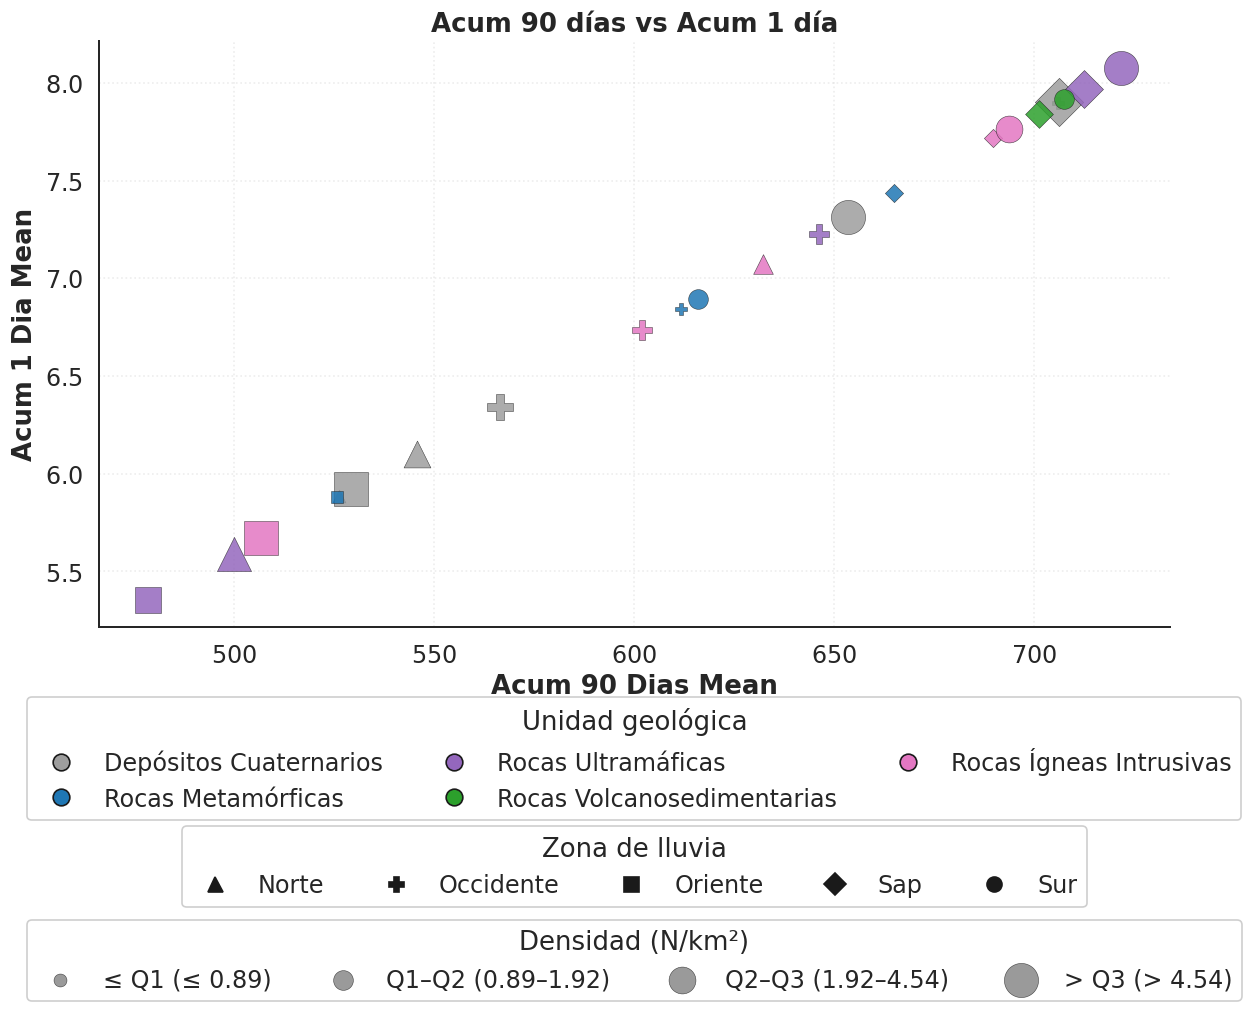

In [18]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="acum_90_dias_mean",
    yvar="acum_1_dia_mean",
    title="Acum 90 días vs Acum 1 día",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)

Columnas disponibles para graficar X/Y:
 ['num_eventos', 'intensidad_promedio', 'intensidad_maxima_promedio', 'duracion_promedio', 'acumulado_promedio', 'acum_1_dia_mean', 'acum_15_dias_mean', 'acum_30_dias_mean', 'acum_60_dias_mean', 'acum_90_dias_mean']


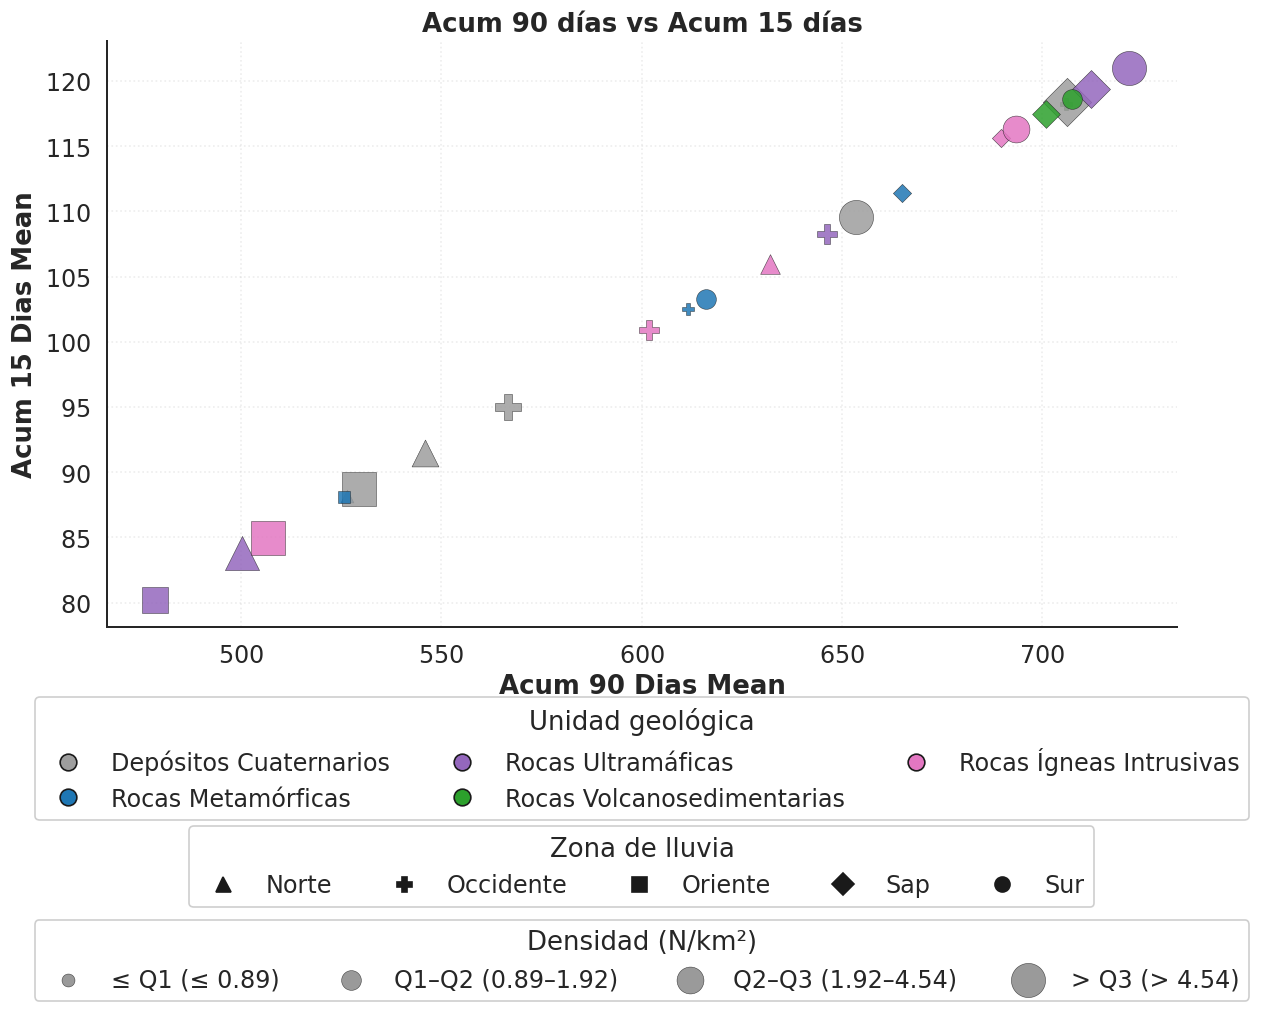

In [19]:
print("Columnas disponibles para graficar X/Y:\n", rain_cols)

ax =scatter_lluvia(
    df_final,
    xvar="acum_90_dias_mean",
    yvar="acum_15_dias_mean",
    title="Acum 90 días vs Acum 15 días",
    ZONA_COL="NOMBRE",   # cámbialo si tu columna tiene otro nombre
)